In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel\\"


In [2]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


In [3]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [4]:
[integer_to_token[i] for i in [239, 144, 240, 145, 239]]
[integer_to_token[i] for i in [239, 144, 240, 129, 239]]

['p400_4(0p)', 'p400_2(5)', 'p500_4(0p)', 'p500_2(4)', 'p400_4(0p)']

In [5]:
with open(data_folder + 'data_token_features.pkl', 'rb') as f:
    df_token_features = pickle.load(f)
    

In [6]:
tokens_info\
.assign(cod_simp = lambda df: df.index.str.replace("\)p", ");p", regex = True).str.replace("\(.+?\)", "", regex = True))\
.assign(cod = lambda df: df["cod"].str.replace("\(.+?\)", "", regex = True))
# \
# .groupby(["cod", "cod_simp", "n"], as_index = False, dropna = False)["cnt"].sum()
# \
# .iloc[240:300]

,n,cnt,cod,hpts,vpts,limhteam,limvteam,cod_simp
token,,,,,,,,
p400_1(1),1,5356,_1,2,0,0,0,p400_1
p500_1(1),1,5004,_1,0,2,0,0,p500_1
p440_1(1a),1,24519,_1,2,0,0,0,p440_1
p550_1(1a),1,22916,_1,0,2,0,0,p550_1
p440_1(1a)p300_9(0),2,853,_1_9,2,0,0,0,p440_1;p300_9
...,...,...,...,...,...,...,...,...
p300_9(0)p440_8(0)p440_8(0)p550_8(0)p550_8(0)p550_8(0),6,384,_9_8_8_8_8_8,0,0,0,0,p300_9;p440_8;p440_8;p550_8;p550_8;p550_8
p200_9(1),1,50,_9,0,0,0,0,p200_9
p300_9(1),1,50,_9,0,0,0,0,p300_9


In [7]:
# xdf = df_token_features\
# .assign(token = lambda df: df["target_tokens"].map(integer_to_token))\
# .assign(cod_simp = lambda df: df["token"].str.replace("\)p", ");p", regex = True).str.replace("\(.+?\)", "", regex = True))\
# .assign(cod = lambda df: df["cod_simp"].str.replace("p[0-9]{3}", "", regex = True))\
# .assign(last_cod_simp = lambda df: df.groupby("game_id")["cod_simp"].shift(1).fillna(""))\
# .assign(last_cod = lambda df: df.groupby("game_id")["cod"].shift(1).fillna(""))

In [8]:
# xdf\
# .query("last_cod_simp in ['p400_1', 'p440_1']")\
# .groupby(["last_cod", "cod", "cod_simp"], as_index = False, dropna = False).size()\
# .sort_values("size", ascending = False)\
# .assign(perc = lambda df: df["size"].cumsum() / df["size"].sum())\
# .iloc[:60]

In [9]:
with open(data_folder + 'data_time_features.pkl', 'rb') as f:
    df_time_features = pickle.load(f)
    

In [10]:
def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

In [11]:
dict_incertezas = \
{"201819": {1: [0.9162221560861702, 0.9564997199223456, 0.9589419221485993, 0.9517255227681384, 0.9471331444229348, 0.9554420228933583, 0.9627180899908172, 0.9582891512586322, 0.9649614097397718, 0.9632434749767783, 0.9624593450657162, 0.9600631441428363, 0.9618906003048752, 0.9664420663231602, 0.9501947528839206, 0.96123301592081, 0.965057232049948, 0.9608206995553377, 0.9612916539735262, 0.9656495392448636, 0.9603052180976808, 0.957421875, 0.9512454983314109, 0.9453344408844586, 0.9470194003527337, 0.9615905325443788, 0.95080078125, 0.9488314970300303, 0.9520358480743908, 0.9594485823442053, 0.9513215879380271, 0.9433466288186491, 0.9444850255661067, 0.9476649804673181, 0.9338925123568579, 0.9270181060727447], 
            2: [0.9152290649861967, 0.9588551512287334, 0.9640628531559242, 0.9514807813484563, 0.9499381886589626, 0.9507860202553388, 0.9606156530687576, 0.9561897675736961, 0.9565679332771745, 0.9591760856632956, 0.9658137764909885, 0.9604316883165466, 0.9523128457977342, 0.9580916061503509, 0.961010101010101, 0.9663594135578458, 0.964905753968254, 0.9599921182913113, 0.9629739855047093, 0.9668047712920579, 0.9559552120491478, 0.9594519631237398, 0.9598442906574395, 0.9566758116140831, 0.9546772754312909, 0.9587939342403627, 0.9662027000136153, 0.9661273851115292, 0.963389349112426, 0.9572888461874399, 0.9562747138397503, 0.9595280139636007, 0.9510998604964848, 0.9506451340866925, 0.9420327830669345, 0.9667521754438911], 
            3: [0.903364240916955, 0.9618145501076746, 0.9492360352311212, 0.9556637503349008, 0.9574095433380324, 0.9623193027210883, 0.9575995238261965, 0.970614596113852, 0.9609248888528168, 0.9638828017206396, 0.9710407896646829, 0.9573217975206612, 0.952657620953933, 0.964516014739229, 0.9537906378428948, 0.9612836713654319, 0.9668475503306645, 0.9609771438771261, 0.9607256235827665, 0.9659889348571653, 0.9600218870763654, 0.9549797473361943, 0.9581940383696956, 0.9591598163267214, 0.9646754535147392, 0.9547522987427284, 0.9492306475218544, 0.9558664146187776, 0.9591360256701907, 0.9618959679901508, 0.9547305780399922, 0.9561969235699407, 0.9587445774012286, 0.9511869018577593, 0.9539030612244898, 0.962775828833467], 
            4: [0.9056655442411458, 0.9688118980943925, 0.9689885945894995, 0.9556037953853156, 0.9591820987654321, 0.95840830449827, 0.9550444444444445, 0.9519391018422594, 0.9561062520246193, 0.9573019133066696, 0.9637946697424695, 0.95520900229083, 0.9578519878082203, 0.9581422219109975, 0.9596126535391872, 0.9617461476754349, 0.9592444444444445, 0.9590723159468464, 0.9582593336632991, 0.9632144638139396, 0.9666928718566211, 0.9592472323497413, 0.959047901836946, 0.9592924037460978, 0.9591701960922435, 0.964378462603878, 0.9632715485756027, 0.9599358974358975, 0.9644847987414931, 0.9628591715976331, 0.9641008890567424, 0.9552862358387595, 0.9613054412437128, 0.9493266069095987, 0.9532086887522317, 0.9655198430662442]
            },
 "201920": {1: [0.9270914127423823, 0.9598315233741909, 0.9512078951379362, 0.9583577316337102, 0.9545284494779445, 0.9630565929330652, 0.9545700378583017, 0.9602800863525016, 0.9601427721594289, 0.950623384085033, 0.9581108503667427, 0.9655158424276847, 0.9667063020214031, 0.9640176393319572, 0.958933186829652, 0.960730986294007, 0.950437674213898, 0.9549632352941176, 0.9696941264777631, 0.9611522633744857, 0.9549119409035629, 0.9581108503667426, 0.9516269134923461, 0.952246165084003, 0.9531393480257117, 0.9480250475928209, 0.944296446267782, 0.9457186170472883, 0.9446182292524158, 0.9341757145542079, 0.9402985074626865, 0.937290212584581, 0.9426637799209677, 0.938300777147658, 0.9393134156851479, 0.9294996751137101], 
            2: [0.8857521524234694, 0.9545899356392789, 0.9564281359548849, 0.9553687283737025, 0.9509311994161269, 0.9573521039283681, 0.9603812224322621, 0.9631863931043873, 0.9614395344914826, 0.9624064755177658, 0.9611258217677137, 0.96484375, 0.9538483796296297, 0.9603328458547313, 0.9603954214360042, 0.9517695473251029, 0.9636657049244461, 0.9678604485582057, 0.955026161895968, 0.966282894736842, 0.958752506126086, 0.9446272262623074, 0.9614206567271745, 0.9615899623090657, 0.9594594594594595, 0.9658637545785052, 0.9605663515761289, 0.9449442454945118, 0.950991094513071, 0.9523031443160441, 0.9541509621106924, 0.951047003787035, 0.9528258216555149, 0.954576290349935, 0.951548713780081, 0.9588520188589561], 
            3: [0.90314035818409, 0.9524131013463987, 0.9431479289940828, 0.9596595293209876, 0.9572387176001053, 0.9522448979591837, 0.9579013630349045, 0.9583493528130206, 0.9510190664036817, 0.9613895107640399, 0.9581811541271001, 0.9624929707477002, 0.9655172413793104, 0.9479145667328035, 0.9601447503545405, 0.9604100143458744, 0.9610595347645284, 0.9578386268555565, 0.9635282177772639, 0.9649127096679544, 0.961665375759955, 0.9601113986228674, 0.9511657214870826, 0.9525620518786143, 0.9584894816872404, 0.9530873879467154, 0.9537002669987189, 0.9477961033950617, 0.9566202788795068, 0.956399165296223, 0.9610447158180089, 0.9479602472071754, 0.9503247588911263, 0.9425159255835159, 0.945093920559219, 0.955351240911003], 
            4: [0.914066702528241, 0.9698512790005949, 0.9517604703395428, 0.9494436979306639, 0.9542362544567461, 0.9533588535260706, 0.9644966264080013, 0.9642372653955665, 0.9457107594244559, 0.9587289992695398, 0.9546634133228564, 0.9566039746390325, 0.9664723797521529, 0.9606632653061224, 0.9633827132991757, 0.9602411334209044, 0.958779668136946, 0.9631271160357032, 0.9593777777777778, 0.9659309405543983, 0.9547992118596359, 0.9569236507006234, 0.9614666666666667, 0.9577496509166253, 0.9517601350952398, 0.9694312441279395, 0.9595511334727796, 0.9621546030041579, 0.9597142893327085, 0.9610699588477366, 0.9541257468328415, 0.9501385041551246, 0.9550874651949706, 0.967116460832505, 0.9507432602670698, 0.953512396694215]
            },
 "202021": {1: [0.9211867769604102, 0.9553284439092835, 0.9511594794759439, 0.9584297839506173, 0.9580198688271605, 0.9531000238070946, 0.9563046192259675, 0.95928387224757, 0.9692214532871972, 0.9586423988933547, 0.9557515051414566, 0.9544412254896477, 0.9609251835502906, 0.9566759002770083, 0.9574144087376601, 0.9531761944349356, 0.9598281353284057, 0.9559877658506631, 0.9477622443235127, 0.963616802777642, 0.9536643129687294, 0.9539400074591081, 0.9554280096575055, 0.9482441687885513, 0.9483130353708992, 0.9511504747991235, 0.9479051337334654, 0.9442606595253098, 0.9566161728670083, 0.9506850077968366, 0.9507320933913731, 0.934126233984457, 0.9385499615529982, 0.9457291666666666, 0.942129793093708, 0.9284244897959184], 
            2: [0.9002488657214709, 0.9521944252077562, 0.9595139801088384, 0.9633363305935841, 0.9458655562165378, 0.9499631337738004, 0.9642469892581937, 0.963032383075189, 0.9619270048783184, 0.9596159122085048, 0.9605822535115465, 0.9710479401887757, 0.9632783528324739, 0.9628561983471075, 0.9612271761654655, 0.9685625729581774, 0.957774825906694, 0.9519675925925926, 0.9633246527777778, 0.9614150406293671, 0.9606894429055094, 0.954755796992103, 0.9629232722571026, 0.9545717592592592, 0.9566759002770083, 0.9539151258632212, 0.9577100646352723, 0.9563303008771215, 0.9524503234077268, 0.955911525490974, 0.950268351800554, 0.9545074206191922, 0.9519533711405167, 0.9510548239720505, 0.9581599286563615, 0.9596208875228996], 
            3: [0.8990048235823623, 0.9466666666666667, 0.9520066663663799, 0.9649155522403964, 0.9621038925646112, 0.951679489585288, 0.9535185094625654, 0.9593322231648181, 0.9688353287124554, 0.962006215936219, 0.9603702479338843, 0.9659459262586653, 0.9573123190020049, 0.9591712244497059, 0.9671600823448682, 0.963520754893843, 0.9603284915489819, 0.9528950403690888, 0.955068438801825, 0.9584667339151791, 0.9690659423570243, 0.9603334868506513, 0.9479882530075581, 0.9663686675180927, 0.9582496347699051, 0.9544430025271499, 0.9570841600399944, 0.9547460821265622, 0.956736, 0.9597846981930027, 0.9422797754396783, 0.9451353948781728, 0.9431387836934729, 0.948942323459698, 0.9511340342524631, 0.9643466976299434], 
            4: [0.9263743202333979, 0.966702470461869, 0.9588652039574296, 0.9624973985431842, 0.9586067168484751, 0.9588107835726883, 0.965087890625, 0.954227609113688, 0.9588892561983471, 0.9571191135734072, 0.9644367354805066, 0.9580165394200092, 0.9642843951985226, 0.9562769319161161, 0.9578399463026052, 0.960737280646383, 0.961747254134579, 0.9612360249305565, 0.9480437230249578, 0.9630612244897959, 0.9613465817221984, 0.9603641667924149, 0.9642891589506173, 0.9585915977961432, 0.958129655097289, 0.9622406894429055, 0.9594286032523948, 0.9591347434599605, 0.9429118575643083, 0.9591472379752153, 0.9575201726402701, 0.9504600915496259, 0.9484905876951332, 0.9495975871356913, 0.9537130135018673, 0.9580881608813197]
            },
 "202122": {1: [0.9136488682816314, 0.9566466541266201, 0.954569894630404, 0.9610048454211322, 0.9476930401662049, 0.95794921875, 0.9577226813590449, 0.9590130671211752, 0.9581862338125868, 0.9604858990088844, 0.9547024501979456, 0.9589208460182662, 0.9617591164975439, 0.954825996430696, 0.9582011834319527, 0.9584285932022557, 0.9593222531203518, 0.9500594530321046, 0.9478689434957657, 0.9614450745641672, 0.958435563016529, 0.9555760294824548, 0.9449653979238755, 0.9443878838506452, 0.9418162153501041, 0.9443973146489878, 0.9540638013087448, 0.9479777777777778, 0.9511919123904647, 0.9448130859148952, 0.9467677136596055, 0.9472212838821652, 0.9402921806019375, 0.9439830399888176, 0.9344236840743233, 0.9235281484066686], 
            2: [0.8940613720833501, 0.9591276353995708, 0.9641698215251487, 0.9576720888712557, 0.9611704795339686, 0.9592781018376387, 0.9579138562079572, 0.9624169637830737, 0.9594765099503136, 0.9530945944756052, 0.9604148571133719, 0.962112323426428, 0.955594052892417, 0.963050682164217, 0.9567638119403803, 0.9563076590103616, 0.9578881473543486, 0.9585261658953365, 0.9665522163496778, 0.9659850845558628, 0.9564340134297521, 0.9616556901892716, 0.9610702276721586, 0.9557208448117539, 0.956651458044039, 0.9598431584640347, 0.9497527288928492, 0.9532784682900616, 0.9624695828384922, 0.9565110197324974, 0.9572422283779625, 0.9533171349119095, 0.9429644510437593, 0.9538852755635973, 0.9544500775456476, 0.9627121130617634], 
            3: [0.896011178603285, 0.9582322863403946, 0.9539308781540384, 0.9666097253021252, 0.9517562126891573, 0.955859375, 0.960186721191312, 0.9631183673469388, 0.9655060465871277, 0.9535836734693878, 0.9542803350122766, 0.9535318853439296, 0.9600854311823815, 0.949026134122288, 0.9667600624476588, 0.9645416441319632, 0.9556574394463668, 0.960842652440067, 0.960440331564405, 0.9624401219335171, 0.9519375573921028, 0.9614458080458225, 0.9584534311584708, 0.954949494949495, 0.9498327155984814, 0.9536489894237645, 0.9598138186569221, 0.9563797358107127, 0.9505916070415668, 0.9577539528896138, 0.9491549115307109, 0.9485110302179729, 0.9479473706694007, 0.9488552825036757, 0.9470928937402538, 0.9606164383561643], 
            4: [0.9323705253972691, 0.9631798472994627, 0.9667455621301776, 0.962054331486849, 0.9619129662985877, 0.960227640173317, 0.9568349347322737, 0.955958075786079, 0.9566161728670082, 0.9675606596407689, 0.95568359375, 0.9577492402705616, 0.9540684781801398, 0.9570000000000001, 0.9606583764676178, 0.9554183141086385, 0.9578407236064894, 0.9561935877420622, 0.9605707206629929, 0.959603305785124, 0.9699218934911242, 0.9654712006489995, 0.947828089569161, 0.9525956100536596, 0.9602851414568946, 0.9541112426035503, 0.9469083380459892, 0.9641628100154266, 0.9542353237591333, 0.9572274893766607, 0.9593550012597631, 0.9545468464514285, 0.9477870113881194, 0.9563665681268476, 0.949826467481515, 0.963113247368636]
            },
 "202223": {1: [0.9265208949704142, 0.949121570470149, 0.9490441503368557, 0.9524793388429752, 0.9489149202344889, 0.9604807867419414, 0.9437195781503515, 0.9661439301217762, 0.9586991814635059, 0.9596759801677517, 0.9553231214753848, 0.96314453125, 0.9560977287777023, 0.9590319381075183, 0.9598850928490817, 0.9457196867404807, 0.9558145690528564, 0.952098413828567, 0.9604224058769513, 0.9592538987242282, 0.9605546666666667, 0.9482464009568969, 0.9530001217087914, 0.9546120905829251, 0.947604550552796, 0.9501577029468505, 0.9494097123615562, 0.9432190743826858, 0.9586056191467222, 0.9513316405856758, 0.9486019736842105, 0.9412804076265615, 0.9399983467365761, 0.9380048773052888, 0.9483976444818336, 0.9263863380938023], 
            2: [0.9017046389989996, 0.9587065271689802, 0.958171265478024, 0.9573125503896802, 0.9641283448165358, 0.9524398185450492, 0.9559423517492539, 0.9621756946658636, 0.9628466483011937, 0.9555862889954834, 0.9563016994316058, 0.9587205576029483, 0.9609781477627471, 0.9575621513909556, 0.9587244902560218, 0.9625246548323472, 0.9535067637877211, 0.9587409343902851, 0.9631339850011211, 0.9593966527261583, 0.9666210507526626, 0.9591281528621528, 0.9612168359133666, 0.9464234448832645, 0.941752563374185, 0.9539591836734694, 0.9579502433747972, 0.9472182346556494, 0.955895347926757, 0.9632559922939521, 0.9557360662260653, 0.9526718474603428, 0.948716290499903, 0.9550322340028771, 0.9509010560146923, 0.9580791308130591], 
            3: [0.908286642826358, 0.9619135802469136, 0.9595224977043159, 0.9561914672216442, 0.9497246877054569, 0.9646045918367346, 0.9595031495366594, 0.9553751354121772, 0.961759130974339, 0.9640600598148393, 0.9623609208460021, 0.9667120653741388, 0.968639701407765, 0.9584868682950729, 0.9572566880550561, 0.9663056681195071, 0.9587631187784333, 0.9642485178657266, 0.9607264922580238, 0.9595767195767196, 0.9618716537775134, 0.9628112765122177, 0.9594400388747014, 0.9628099173553719, 0.960616903437607, 0.9611301887003502, 0.956221944560137, 0.9574343498040628, 0.9505078125, 0.9369259686445385, 0.9551738006320023, 0.9507621328682907, 0.9454867638079045, 0.957642921839203, 0.956715976331361, 0.9581758034026465], 
            4: [0.9187400232707554, 0.9670581669052877, 0.966071650499408, 0.9609467455621302, 0.9580688393294224, 0.9627378579442103, 0.9556905610808781, 0.9550260145681582, 0.95880859375, 0.9563617671725779, 0.9652525252525253, 0.9593559752101569, 0.9642987545133677, 0.9610350981558596, 0.9600468447367235, 0.968445452254976, 0.9518614398422091, 0.952948585719371, 0.958076005620364, 0.963910632288715, 0.967207476341624, 0.9508624723934943, 0.9629971622899869, 0.961811762012521, 0.9635103723520898, 0.9602127465303142, 0.9522312129466431, 0.958477903579255, 0.9649495273193398, 0.9569386831237701, 0.945070041890005, 0.9503595656098058, 0.9518161045836507, 0.957259003473017, 0.955484693877551, 0.9589772851436827]
            }}

dict_incertezas_tempo = \
{"201819": {1: [0.9558732629747487, 0.9883288188396344, 0.9820579404896619, 0.9549383448489882, 0.9397824724817402, 0.9430252861669792, 0.9406611570247934, 0.9380441078191134, 0.9299607646715085, 0.9431963172023803, 0.9392737803519715, 0.9429888227609232, 0.9434484564524124, 0.939456995640111, 0.9327043659527111, 0.9435244081448304, 0.942060353798127, 0.942894156367074, 0.9449003056180658, 0.9370361074258668, 0.9397322039776929, 0.9452734375, 0.9387596967482323, 0.9394604643803647, 0.9408919123204837, 0.940989349112426, 0.94048828125, 0.9387938262420141, 0.9393175392215904, 0.9416499450169484, 0.9351724392790163, 0.9302397751024544, 0.9356966764061359, 0.937066013133503, 0.9367519505453357, 0.8590546386796988], 
            2: [0.8461601183473307, 0.9834888941398865, 0.988846414638221, 0.9478176853602185, 0.9419188390217684, 0.9433709324368199, 0.9416449480430867, 0.9366319444444444, 0.9355918311590739, 0.9387269482450922, 0.9401878398418191, 0.9453001524375988, 0.9383115661108812, 0.9386993387155665, 0.9447199265381083, 0.94104732181739, 0.9383503401360545, 0.935443879771102, 0.9391477889429642, 0.9386046977847572, 0.9339080459770115, 0.9371923676355344, 0.9388754325259516, 0.9385954884926078, 0.9406045508625818, 0.9400687358276644, 0.9472041558006304, 0.9471647406611126, 0.943715976331361, 0.9381120136644636, 0.9450780437044745, 0.9386642713511416, 0.9399211019853845, 0.9440040479001518, 0.9389466328937025, 0.9489210804285498], 
            3: [0.8406750108131488, 0.9854093193096345, 0.9816539791969767, 0.9544442494064171, 0.9453628946131829, 0.9378011621315192, 0.9376422394173874, 0.9356340442564892, 0.9324279234189145, 0.9309850390931472, 0.9345877485847003, 0.9335614669421487, 0.9407068882039655, 0.9433106575963719, 0.9349460389588693, 0.9421551715338525, 0.9396376020158065, 0.9373305340461883, 0.9472612748803225, 0.941283988954511, 0.9346636571936664, 0.9423895563333649, 0.9479201854418805, 0.945000888439993, 0.9418048469387754, 0.9448536310752486, 0.9417546774257347, 0.9420373871035497, 0.9400031129895475, 0.947048322560788, 0.943767926589023, 0.9399134754045826, 0.9399559398685959, 0.9395289923062488, 0.944438775510204, 0.9546102177895379], 
            4: [0.8159053105602662, 0.9487142271702753, 0.9703671411066075, 0.9532229263681243, 0.9326234567901235, 0.938356401384083, 0.9396444444444445, 0.9461060312598532, 0.946202970984312, 0.9374121716571181, 0.9420939276709979, 0.9384926530494877, 0.9371558604423258, 0.9341759742305942, 0.9348968930893871, 0.9416793381305301, 0.9468444444444445, 0.9261510673982499, 0.9388689938956337, 0.9472567348194675, 0.9375155489655584, 0.9376209419561661, 0.9366899662143184, 0.9446618106139438, 0.939393672569099, 0.939404432132964, 0.9473383856829803, 0.9476084812623273, 0.9396566464895181, 0.9407621301775148, 0.9426042931947861, 0.9384809364296737, 0.9447683279987806, 0.9373001216161434, 0.9449761951993652, 0.9522659825964489]
            },
 "201920": {1: [0.9614127423822715, 0.9839190225250143, 0.9843202255753696, 0.9511508490608531, 0.9397000306091216, 0.9320999712726228, 0.9457364341085271, 0.9437702039127079, 0.9325736168947055, 0.9347199080723929, 0.9392012152954914, 0.9328370319282729, 0.942140309155767, 0.9339463313942578, 0.9444992445903931, 0.9376619188390218, 0.9380654310724241, 0.9439878892733564, 0.9335710264589979, 0.9374759945130315, 0.9360163956578532, 0.9414685576301738, 0.9355072979708081, 0.9408098977355734, 0.9351182277318641, 0.9345673543180757, 0.9389685119079333, 0.9385055503936623, 0.9369182254530718, 0.9359395104743454, 0.9425540209400757, 0.9321221162555278, 0.9403927387242805, 0.9375918924595673, 0.9429402470554439, 0.8592216408467562], 
            2: [0.8550900829081632, 0.9793556400316158, 0.9819006249047401, 0.9634785899653979, 0.9348225573120984, 0.9378914134879147, 0.9435255198487713, 0.9381971282244636, 0.9302369708213865, 0.9382968081740142, 0.9400794375456538, 0.9405864197530864, 0.943359375, 0.9344851432393521, 0.9389177939646202, 0.9403566529492455, 0.9387989632744878, 0.9453898184407262, 0.93419513696522, 0.9378462603878116, 0.9290265092448207, 0.9358375116852213, 0.9410161704427729, 0.9421989684586392, 0.9385728634039445, 0.9451124031535518, 0.9370157004340948, 0.9321338108131714, 0.939936799770181, 0.9370814297231927, 0.9432156318190835, 0.9443361550456671, 0.9434555120705859, 0.9439764825597828, 0.9424376365391455, 0.9519404940840945], 
            3: [0.8584173261141191, 0.9812893021102581, 0.986698224852071, 0.9485677083333333, 0.9373273102056927, 0.9385714285714286, 0.9415860536221272, 0.9341919774445726, 0.9307199211045365, 0.9358613884497448, 0.9308345507669832, 0.9330390773376905, 0.9340784780023781, 0.9304714108372503, 0.9379431757054135, 0.9394002498958767, 0.9368775407983786, 0.9430072071837245, 0.9396333551727238, 0.9375275074575774, 0.9379197657269572, 0.9368668040875401, 0.9373293425750893, 0.9407948456952383, 0.94223009781971, 0.937642279079393, 0.9362675255325008, 0.9368489583333334, 0.9437956910490458, 0.9460897444756153, 0.944701481838679, 0.9379192906739479, 0.9456615543005951, 0.9387165816035764, 0.9394122002031645, 0.9465176371612283], 
            4: [0.8056812069049831, 0.9539559785841761, 0.9730149293169507, 0.9554635850577802, 0.9354710076937511, 0.9447077845800915, 0.9403975367868815, 0.9486143617417748, 0.9469918292740084, 0.9399653031409789, 0.9273890882021485, 0.9383557994565507, 0.9387471119512707, 0.9429336734693877, 0.9493484072176431, 0.9380277725652092, 0.9312906952320941, 0.937149892274546, 0.9347333333333333, 0.9298790257971479, 0.9364327265903546, 0.9411529649954713, 0.9326666666666666, 0.9395072294040809, 0.9415335199159197, 0.9417083100720306, 0.9386907117417603, 0.9407284396109328, 0.9404896087942148, 0.942962962962963, 0.9396808619955667, 0.9395669625190797, 0.9413277728527013, 0.9467736005773342, 0.9395628621819098, 0.9463670798898072]
            },
 "202021": {1: [0.9588077287018101, 0.9877499029744549, 0.9874946192646881, 0.9581404320987654, 0.9413821373456791, 0.9354374270199186, 0.9442971566440825, 0.9378843483435827, 0.9243079584775087, 0.9324793865525166, 0.9396611433747136, 0.93582845829465, 0.9401603531372461, 0.9399076638965835, 0.9439455996639361, 0.9395569465499536, 0.943122408509104, 0.9399983467365761, 0.9392944267217113, 0.9412929727615043, 0.9329853953773958, 0.9373434919281795, 0.9413465569836198, 0.94031944009477, 0.9367169745352835, 0.9403305332359387, 0.9427189557718082, 0.93696177273682, 0.9455335263978615, 0.9391568278012921, 0.9424783763921081, 0.9342049989498005, 0.9332846772406782, 0.9466319444444444, 0.9393404420591767, 0.8521469387755102], 
            2: [0.8393007352652752, 0.98571675900277, 0.9846359542127978, 0.9539392864832006, 0.9384112955116609, 0.9418959360407119, 0.9459439922508638, 0.9449981636504097, 0.9408382968726247, 0.9434842249657065, 0.9372513008876645, 0.9412252456433714, 0.9405536340820837, 0.9438677685950413, 0.9391755398871352, 0.9429618001046572, 0.9418615572461726, 0.9416714891975309, 0.9334490740740741, 0.9433776719631489, 0.9388734995383194, 0.9434133091896786, 0.937459958764808, 0.939453125, 0.9407202216066483, 0.9400478948540878, 0.9394644506001847, 0.9359922654894058, 0.9411747567158091, 0.939744098393176, 0.9373701523545707, 0.945405968790828, 0.9427903801722327, 0.9460830421929589, 0.9458605826397146, 0.9503550394404154], 
            3: [0.8476229877114579, 0.9882444444444445, 0.9868249177964956, 0.9578826788853961, 0.9454193099062818, 0.9335710264589979, 0.9403149298254194, 0.9264042060724124, 0.9274574669187146, 0.9403630467096077, 0.9336859504132231, 0.946108366011485, 0.9387112942748942, 0.9348538580039495, 0.9287760459214238, 0.9416175850271056, 0.9343759615486636, 0.9426220684352172, 0.9392977583812736, 0.9301127143546335, 0.939791760977818, 0.9391480969757088, 0.9447384505299563, 0.9462573949296105, 0.9398511687363039, 0.9453930742435626, 0.9465231451827086, 0.9428436818091649, 0.941984, 0.942960399846213, 0.9411235724104263, 0.9377861948103341, 0.9392682111828915, 0.9428303096256764, 0.9476073971213825, 0.948944744211461], 
            4: [0.8207961785823918, 0.9580844341430015, 0.9806341874473331, 0.9486160249739854, 0.9407881495793584, 0.9333534895439657, 0.943359375, 0.948196492045918, 0.9384727272727272, 0.9326192674669129, 0.9337822671156004, 0.9460167298931763, 0.9392428439519852, 0.9337087043952887, 0.9366142779346766, 0.9431749638794205, 0.939808385585434, 0.941833307997402, 0.9382623381497466, 0.935561224489796, 0.9439891654344191, 0.9387857753634123, 0.9323881172839505, 0.9451905417814509, 0.9426069906455522, 0.9448322560787934, 0.9451715304076632, 0.9413927220416645, 0.9440505149836965, 0.9378281873555976, 0.9379339463313942, 0.9425861988157915, 0.945907943067034, 0.9443396074256867, 0.9494039069232979, 0.9514666975089997]
            },
 "202122": {1: [0.968627092289399, 0.9786905099332629, 0.98663820430306, 0.9589960375713292, 0.9362448060941828, 0.941875, 0.9407162534435262, 0.937153369585802, 0.9310449174044273, 0.9354600116601839, 0.9395702008314621, 0.9418162153501042, 0.9371974613646957, 0.9391359309934563, 0.9379218934911243, 0.9424058832495046, 0.935763712456463, 0.9401671290791386, 0.9381507705122866, 0.9361562696912413, 0.9354984504132231, 0.9447804838968115, 0.9339446366782007, 0.9357906735931639, 0.9366287453933665, 0.9276400540421654, 0.9377230814991077, 0.9397333333333333, 0.9372200245022397, 0.9347054511785811, 0.9384587289992696, 0.9369241342356929, 0.939258278967339, 0.937716222670037, 0.9407639356140987, 0.8544793148809364], 
            2: [0.8580552536596493, 0.9872175230400202, 0.982355327203894, 0.9615899623090657, 0.9457196867404807, 0.9444761194684443, 0.9402798441051105, 0.9310414711953462, 0.9384359690570043, 0.9361005203884863, 0.9359912625450417, 0.9377223048567548, 0.9429849568001404, 0.9417747216113207, 0.9392940918757587, 0.9371714056398741, 0.9415696718267568, 0.9410229025750564, 0.9474750202538482, 0.9274710269248275, 0.9379035382231404, 0.9339667300617064, 0.9334317745909204, 0.9392470156106519, 0.9323546915294584, 0.9412689291508924, 0.9329828469592337, 0.9404213396491158, 0.9433015804466444, 0.9382137731247083, 0.9382579255155432, 0.945057787714452, 0.9326772837996525, 0.9489461587363686, 0.9408698145420896, 0.9509755978287447], 
            3: [0.8614171999905036, 0.9868078889700512, 0.9738232067479894, 0.9567210262177848, 0.9436345966958212, 0.94283203125, 0.9321206743566992, 0.9314775510204082, 0.9351333315297279, 0.9340571428571429, 0.9382284721615667, 0.9367887041395008, 0.9406883512482056, 0.9424926035502958, 0.9439315143557242, 0.939308409951325, 0.935, 0.9393830580349509, 0.9380290338143064, 0.9417005370881115, 0.9385858585858586, 0.9421118474788308, 0.945274211236304, 0.9406244260789716, 0.9372615859102346, 0.9412096804546652, 0.9440537312823444, 0.938398170997242, 0.9375354516414732, 0.9400261396802312, 0.9414902910924996, 0.9410113591509144, 0.9383784014695203, 0.944365679479101, 0.9449766094898641, 0.9531572527678738], 
            4: [0.8080190061967837, 0.9683052125553775, 0.9749901380670611, 0.9374548414155088, 0.9414815394923469, 0.9331399377315435, 0.9411304124114943, 0.9413383499059392, 0.9369013143239029, 0.9328454886033403, 0.9399804687500001, 0.9469877680837391, 0.9411664845250347, 0.9405111111111111, 0.9361191768716071, 0.9370541014497489, 0.931760589418247, 0.9393616691307989, 0.9440386176256995, 0.9438677685950413, 0.9346650887573964, 0.9413703353163873, 0.9367736678004535, 0.9430837150153535, 0.9400935620405436, 0.9400236686390533, 0.9398920721946917, 0.9399944622443732, 0.9423834719072814, 0.9393616691307989, 0.9329100529100529, 0.9438495850728291, 0.9425915666358881, 0.941402848696587, 0.9453246818570494, 0.9527375716561594]
            },
 "202223": {1: [0.9602787536982249, 0.9867648210509828, 0.9854998119079375, 0.9578765390453702, 0.9385345478231201, 0.9403521552013342, 0.9333423472147107, 0.9385835923535472, 0.9333355999626006, 0.9337606008643633, 0.9369189147995732, 0.939296875, 0.9381412268556342, 0.9278635191430272, 0.9437604733080264, 0.9348983449712588, 0.9351685362492127, 0.9374233614176655, 0.9361799816345271, 0.943189333742296, 0.9236906666666667, 0.9380366525695245, 0.93977443303988, 0.9386019057906716, 0.9327431501361961, 0.9387867590768508, 0.9398961418313116, 0.941890228626823, 0.9428928199791883, 0.9390946409995414, 0.9367209141274238, 0.9374383629191322, 0.9359832784213696, 0.9339087029416248, 0.9359216520372693, 0.8501548751404842], 
            2: [0.8521991869403883, 0.9787165180927185, 0.981770085537021, 0.9558935769954314, 0.9440594456016664, 0.9421308815575987, 0.9404989001560775, 0.9395023677094035, 0.9396877869605142, 0.9368719582647667, 0.9367865118998553, 0.9436588687710303, 0.9393340270551509, 0.9398108265678161, 0.9412114817520223, 0.9450608152531229, 0.9366701352757544, 0.942064429077416, 0.9386009351460439, 0.9263273872797387, 0.9299186563421704, 0.9333033729505894, 0.9368696756902568, 0.9344744376595464, 0.92954215476738, 0.9418122448979591, 0.9410830178474852, 0.9315500157557508, 0.9428977304504423, 0.9388846804889226, 0.9368309701963295, 0.940694600224323, 0.9401613067137221, 0.9473067291810965, 0.9426939853076217, 0.9524769493575529], 
            3: [0.8558573774883808, 0.9830092592592593, 0.980257116620753, 0.9540478668054111, 0.9420611439842209, 0.9401218820861678, 0.9390827527245211, 0.939044135633496, 0.9374835315217299, 0.9388480029397054, 0.9383708109191753, 0.9373297548469797, 0.9457787334171771, 0.9386234421092385, 0.9383631036591488, 0.9426451224366891, 0.939777487500563, 0.942957859317417, 0.9403818232647062, 0.9412345679012346, 0.942035990481856, 0.9436704898725715, 0.9397752297846382, 0.9347075154958677, 0.9420294989430923, 0.9464771087571727, 0.9416678235920218, 0.944191703076438, 0.93439453125, 0.9401939425007476, 0.9402585463947142, 0.9390845575655898, 0.945893847056429, 0.9452288347807555, 0.9366863905325444, 0.9526360008401596], 
            4: [0.8120566358082613, 0.9591108738382392, 0.9788397511790217, 0.9572165680473372, 0.9390974969705238, 0.9449182542016578, 0.9415697128917245, 0.9426222684703435, 0.9328515625, 0.9357826294763232, 0.9350229568411387, 0.9348034428309344, 0.9359811757069252, 0.9364217727543129, 0.9472771496779425, 0.9420811287477954, 0.9391436554898093, 0.9341645293489471, 0.9455064318313019, 0.9311412245508702, 0.9328328141429427, 0.9312567220301968, 0.9456781226070898, 0.9396402187216581, 0.943555107232139, 0.9462655222790358, 0.9421366768146131, 0.9472927319211103, 0.9375901297868932, 0.9428959451594128, 0.9395973154362416, 0.9417222270746596, 0.9426513004282735, 0.9429091741384629, 0.94, 0.9545824278551397]
            }}



In [12]:
df_incerteza_evento = pd.concat([
    pd.DataFrame(dict_incertezas["201819"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '201819'),
    pd.DataFrame(dict_incertezas["201920"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '201920'),
    pd.DataFrame(dict_incertezas["202021"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '202021'),
    pd.DataFrame(dict_incertezas["202122"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '202122'),
    pd.DataFrame(dict_incertezas["202223"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '202223')
    ], axis = 0)


In [13]:
df_incerteza_tempo = pd.concat([
    pd.DataFrame(dict_incertezas_tempo["201819"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '201819'),
    pd.DataFrame(dict_incertezas_tempo["201920"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '201920'),
    pd.DataFrame(dict_incertezas_tempo["202021"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '202021'),
    pd.DataFrame(dict_incertezas_tempo["202122"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '202122'),
    pd.DataFrame(dict_incertezas_tempo["202223"], index = np.arange(0, 7001, 200)).stack().reset_index().rename(columns = {"level_0": "cat_time", "level_1": "period", 0: "incerteza"}).assign(seasondata = '202223')
    ], axis = 0)

### Definição n-gramas eventos

In [14]:
ALPHA = 10
K_EVENTO = 600

In [15]:
df_unigrama_evento = df_token_features\
.query("season_split == 'train'")\
.groupby(["season", "target_tokens"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby("season")["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.sort_values("size", ascending = False)

df_unigrama_evento_smooth = df_unigrama_evento\
.assign(prop_unigram = lambda df: (df["size"] + (ALPHA / K_EVENTO)) / (df["total"] + ALPHA))

df_bigrama_evento = df_token_features\
.query("season_split == 'train'")\
.assign(last_token = lambda df: df.groupby(["game_id"])["target_tokens"].shift(1))\
.groupby(["season", "last_token", "target_tokens"], as_index = False, dropna = False).size()\
.assign(last_token = lambda df: df["last_token"].fillna(0))\
.assign(total = lambda df: df.groupby(["season", "last_token"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.astype({"last_token": "int"})\
.sort_values("size", ascending = False)

df_bigrama_evento_smooth = df_bigrama_evento\
.merge(df_unigrama_evento_smooth[["season", "target_tokens", "prop_unigram"]], on = ["season", "target_tokens"], how = "left")\
.assign(prop_bigram = lambda df: (df["size"] + ALPHA * df["prop_unigram"]) / (df["total"] + ALPHA))\
[["season", "last_token", "target_tokens", "prop_bigram"]]

df_total_bigrama_evento = df_bigrama_evento[["season", "last_token", "total"]].drop_duplicates()

df_trigrama_evento = df_token_features\
.query("season_split == 'train'")\
.assign(last_token = lambda df: df.groupby(["game_id"])["target_tokens"].shift(1))\
.assign(last2_token = lambda df: df.groupby(["game_id"])["target_tokens"].shift(2))\
.groupby(["season", "last2_token", "last_token", "target_tokens"], as_index = False, dropna = False).size()\
.assign(last2_token = lambda df: df["last2_token"].fillna(0))\
.assign(last_token = lambda df: df["last_token"].fillna(0))\
.assign(total = lambda df: df.groupby(["season", "last2_token", "last_token"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.astype({"last2_token": "int", "last_token": "int"})\
.sort_values("size", ascending = False)

In [16]:
df_unigrama_evento_dev = df_token_features\
.query("season_split == 'dev'")\
[["season", "period", "remaining_time", "target_tokens"]]\
.merge(df_unigrama_evento[["season", "target_tokens", "size", "prop"]], how = "left")\
.merge(df_unigrama_evento[["season", "total"]].drop_duplicates(), how = "left")\
.assign(size = lambda df: df["size"].fillna(0))\
.assign(prop_unigram = lambda df: (df["size"] + (10 / 600)) / (df["total"] + 10))

In [17]:
df_bigrama_evento_dev = df_token_features\
.query("season_split == 'dev'")\
.assign(last_token = lambda df: df.groupby(["game_id"])["target_tokens"].shift(1))\
.assign(last_token = lambda df: df["last_token"].fillna(0))\
[["season", "period", "remaining_time", "last_token", "target_tokens"]]\
.astype({"last_token": "int"})\
.merge(df_bigrama_evento[["season", "last_token", "target_tokens", "size", "prop"]], on = ["season", "last_token", "target_tokens"], how = "left")\
.merge(df_bigrama_evento[["season", "last_token", "total"]].drop_duplicates(), on = ["season", "last_token"], how = "left")\
.merge(df_unigrama_evento_smooth[["season", "target_tokens", "prop_unigram"]], on = ["season", "target_tokens"], how = "left")\
.assign(size = lambda df: df["size"].fillna(0))\
.assign(total = lambda df: df["total"].fillna(0))\
.assign(prop_bigram = lambda df:(df["size"] + (ALPHA * df["prop_unigram"])) / (df["total"] + ALPHA))


In [18]:
df_trigrama_evento_dev = df_token_features\
.query("season_split == 'dev'")\
.assign(last_token = lambda df: df.groupby(["game_id"])["target_tokens"].shift(1))\
.assign(last2_token = lambda df: df.groupby(["game_id"])["target_tokens"].shift(2))\
.assign(last2_token = lambda df: df["last2_token"].fillna(0))\
.assign(last_token = lambda df: df["last_token"].fillna(0))\
[["season", "period", "remaining_time", "last2_token", "last_token", "target_tokens"]]\
.astype({"last2_token": "int", "last_token": "int"})\
.merge(df_trigrama_evento[["season", "last2_token", "last_token", "target_tokens", "size", "prop"]], on = ["season", "last2_token", "last_token", "target_tokens"], how = "left")\
.merge(df_trigrama_evento[["season", "last2_token", "last_token", "total"]].drop_duplicates(), on = ["season", "last2_token", "last_token"], how = "left")\
.merge(df_bigrama_evento_smooth, on = ["season", "last_token", "target_tokens"], how = "left")\
.merge(df_total_bigrama_evento, on = ["season", "last_token"], how = "left", suffixes = ("", "_bigram"))\
.merge(df_unigrama_evento_smooth[["season", "target_tokens", "prop_unigram"]], on = ["season", "target_tokens"], how = "left")\
.assign(size = lambda df: df["size"].fillna(0))\
.assign(total = lambda df: df["total"].fillna(0))\
.assign(total_bigram = lambda df: df["total_bigram"].fillna(0))\
.assign(prop_bigram = lambda df: df["prop_bigram"].fillna((ALPHA * df["prop_unigram"]) / (df["total_bigram"] + ALPHA)))\
.assign(prop_trigram = lambda df: (df["size"] + ALPHA * df["prop_bigram"]) / (df["total"] + ALPHA))

### Definição n-gramas tempo

In [19]:
df_unigrama_tempo = df_time_features\
.query("season_split == 'train'")\
.groupby(["season", "target_time"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby(["season"])["size"].transform("sum"))\
.assign(prop_unigram = lambda df: (df["size"] + (10 / 301)) / (df["total"] + 10))\
.sort_values("size", ascending = False)

df_bigrama_tempo = df_time_features\
.query("season_split == 'train'")\
.assign(token = lambda df: df["token_features"].str[-1])\
.groupby(["season", "token", "target_time"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby(["season", "token"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.sort_values("size", ascending = False)

df_bigrama_tempo_smooth = df_bigrama_tempo\
.merge(df_unigrama_tempo[["season", "target_time", "prop_unigram"]], on = ["season", "target_time"], how = "left")\
.assign(prop_bigram = lambda df: (df["size"] + ALPHA * df["prop_unigram"]) / (df["total"] + ALPHA))\
[["season", "token", "target_time", "prop_bigram"]]

df_total_bigrama_tempo = df_bigrama_tempo[["season", "token", "total"]].drop_duplicates()

df_trigrama_tempo = df_time_features\
.query("season_split == 'train'")\
.assign(last_token = lambda df: df["token_features"].str[-2])\
.assign(token = lambda df: df["token_features"].str[-1])\
.groupby(["season", "last_token", "token", "target_time"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby(["season", "last_token", "token"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.sort_values("size", ascending = False)

In [20]:
ALPHA = 10
K_TEMPO = 301
EPS = 1e-12


In [21]:
df_bigrama_tempo_dev = df_time_features\
.query("season_split == 'dev'")\
.assign(token = lambda df: df["token_features"].str[-1])\
[["season", "token", "target_time"]]\
.astype({"token": "int"})\
.merge(df_bigrama_tempo[["season", "token", "target_time", "size", "prop"]], how = "left")\
.merge(df_bigrama_tempo[["season", "token", "total"]].drop_duplicates(), how = "left")\
.merge(df_unigrama_tempo[["season", "target_time", "prop_unigram"]].drop_duplicates(), how = "left")\
.assign(prop_unigram = lambda df: df["prop_unigram"].fillna(1e-12))\
.assign(size = lambda df: df["size"].fillna(0))\
.assign(total = lambda df: df["total"].fillna(0))\
.assign(prop_bigram = lambda df: (df["size"] + 10 * df["prop_unigram"]) / (df["total"] + 10))

df_bigrama_tempo_dev = df_time_features\
.query("season_split == 'dev'")\
.assign(token = lambda df: df["token_features"].str[-1])\
[["season", "period", "remaining_time", "token", "target_time"]]\
.astype({"token": "int"})\
.merge(df_bigrama_tempo[["season", "token", "target_time", "size", "prop"]], on = ["season", "token", "target_time"], how = "left")\
.merge(df_bigrama_tempo[["season", "token", "total"]].drop_duplicates(), on = ["season", "token"], how = "left")\
.merge(df_unigrama_tempo[["season", "target_time", "prop_unigram"]].drop_duplicates(), on = ["season", "target_time"], how = "left")\
.assign(prop_unigram = lambda df: df["prop_unigram"].fillna(1 / K_TEMPO))\
.assign(size = lambda df: df["size"].fillna(0))\
.assign(total = lambda df: df["total"].fillna(0))\
.assign(prop_bigram = lambda df: (df["size"] + ALPHA * df["prop_unigram"]) / (df["total"] + ALPHA))

df_trigrama_tempo_dev = df_time_features\
.query("season_split == 'dev'")\
.assign(last_token = lambda df: df["token_features"].str[-2])\
.assign(token = lambda df: df["token_features"].str[-1])\
[["season", "last_token", "token", "target_time"]]\
.astype({"last_token": "int", "token": "int"})\
.merge(df_trigrama_tempo[["season", "last_token", "token", "target_time", "size", "prop"]], how = "left")\
.merge(df_trigrama_tempo[["season", "last_token", "token", "total"]].drop_duplicates(), how = "left")\
.merge(df_bigrama_tempo_dev[["season", "token", "target_time", "prop_bigram"]].drop_duplicates(), how = "left")\
.assign(size = lambda df: df["size"].fillna(0))\
.assign(total = lambda df: df["total"].fillna(0))\
.assign(prop_trigram = lambda df: (df["size"] + (10 * df["prop_bigram"])) / (df["total"] + 10))

df_trigrama_tempo_dev = df_time_features\
.query("season_split == 'dev'")\
.assign(last_token = lambda df: df["token_features"].str[-2])\
.assign(token = lambda df: df["token_features"].str[-1])\
[["season", "period", "remaining_time", "last_token", "token", "target_time"]]\
.astype({"last_token": "int", "token": "int"})\
.merge(df_trigrama_tempo[["season", "last_token", "token", "target_time", "size", "prop"]], on = ["season", "last_token", "token", "target_time"], how = "left")\
.merge(df_trigrama_tempo[["season", "last_token", "token", "total"]].drop_duplicates(), on = ["season", "last_token", "token"], how = "left")\
.merge(df_bigrama_tempo_smooth, on = ["season", "token", "target_time"], how = "left")\
.merge(df_total_bigrama_tempo, on = ["season", "token"], how = "left", suffixes = ("", "_bigram"))\
.merge(df_unigrama_tempo[["season", "target_time", "prop_unigram"]], on = ["season", "target_time"], how = "left")\
.assign(size = lambda df: df["size"].fillna(0))\
.assign(total = lambda df: df["total"].fillna(0))\
.assign(total_bigram = lambda df: df["total_bigram"].fillna(0))\
.assign(prop_unigram = lambda df: df["prop_unigram"].fillna(1 / K_TEMPO))\
.assign(prop_bigram = lambda df: df["prop_bigram"].fillna((ALPHA * df["prop_unigram"]) / (df["total_bigram"] + ALPHA)))\
.assign(prop_trigram = lambda df: (df["size"] + ALPHA * df["prop_bigram"]) / (df["total"] + ALPHA))

### Entropia cruzada n-gramas em validação evento

In [22]:
df_unigrama_evento_dev\
.assign(cross_entropy = lambda df: -np.log(df["prop_unigram"]))\
.groupby("season")["cross_entropy"].mean()\
.describe()

count    6.000000
mean     4.394708
std      0.022779
min      4.368121
25%      4.380639
50%      4.388762
75%      4.411882
max      4.425082
Name: cross_entropy, dtype: float64

In [23]:
sum([4.425082, 4.388531, 4.378008, 4.368121, 4.388993])/5

4.389747

In [24]:
df_trigrama_evento_dev

,season,period,remaining_time,last2_token,last_token,target_tokens,size,prop,total,prop_bigram,total_bigram,prop_unigram,prop_trigram
0,2018-19,1,7200.0,0,0,87,572.0,0.484746,1180.0,0.480683,1180.0,0.001325,4.847116e-01
1,2018-19,1,7200.0,0,87,152,0.0,NaN,572.0,0.000007,572.0,0.000410,1.210203e-07
2,2018-19,1,7000.0,87,152,144,0.0,NaN,0.0,0.099019,177.0,0.051653,9.901886e-02
3,2018-19,1,6750.0,152,144,240,17.0,0.944444,18.0,0.735697,22305.0,0.108509,8.698919e-01
4,2018-19,1,6730.0,144,240,281,700.0,0.042641,16416.0,0.040628,46857.0,0.013468,4.264010e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
257500,2020-21,4,315.0,108,240,41,4.0,0.001078,3712.0,0.000410,41456.0,0.000158,1.075793e-03
257501,2020-21,4,272.0,240,41,322,0.0,NaN,17.0,0.014572,60.0,0.002004,5.397013e-03
257502,2020-21,4,262.0,41,322,55,0.0,NaN,1.0,0.036551,759.0,0.010807,3.322859e-02
257503,2020-21,4,243.0,322,55,366,1.0,0.035714,28.0,0.024875,4094.0,0.008521,3.286173e-02


In [25]:
df_trigrama_evento_dev

,season,period,remaining_time,last2_token,last_token,target_tokens,size,prop,total,prop_bigram,total_bigram,prop_unigram,prop_trigram
0,2018-19,1,7200.0,0,0,87,572.0,0.484746,1180.0,0.480683,1180.0,0.001325,4.847116e-01
1,2018-19,1,7200.0,0,87,152,0.0,NaN,572.0,0.000007,572.0,0.000410,1.210203e-07
2,2018-19,1,7000.0,87,152,144,0.0,NaN,0.0,0.099019,177.0,0.051653,9.901886e-02
3,2018-19,1,6750.0,152,144,240,17.0,0.944444,18.0,0.735697,22305.0,0.108509,8.698919e-01
4,2018-19,1,6730.0,144,240,281,700.0,0.042641,16416.0,0.040628,46857.0,0.013468,4.264010e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
257500,2020-21,4,315.0,108,240,41,4.0,0.001078,3712.0,0.000410,41456.0,0.000158,1.075793e-03
257501,2020-21,4,272.0,240,41,322,0.0,NaN,17.0,0.014572,60.0,0.002004,5.397013e-03
257502,2020-21,4,262.0,41,322,55,0.0,NaN,1.0,0.036551,759.0,0.010807,3.322859e-02
257503,2020-21,4,243.0,322,55,366,1.0,0.035714,28.0,0.024875,4094.0,0.008521,3.286173e-02


In [26]:
df_trigrama_evento_dev\
.assign(cross_entropy_bi = lambda df: -np.log(df["prop_bigram"]))\
.assign(cross_entropy_tri = lambda df: -np.log(df["prop_trigram"]))\
[["season", "period", "remaining_time", "target_tokens", "size", "total", "prop_unigram", "prop_bigram", "prop_trigram", "cross_entropy_bi", "cross_entropy_tri"]]\
.groupby(["season"])[["cross_entropy_bi", "cross_entropy_tri"]].describe()

cross_entropy_bi                                                    \
                   count      mean       std       min       25%       50%   
season                                                                       
2018-19          48371.0  3.135793  2.241793  0.031503  1.824462  2.977220   
2019-20          42805.0  3.093269  2.234757  0.029360  1.765864  2.880976   
2020-21          41208.0  3.100767  2.260003  0.034763  1.777923  2.914138   
2021-22          47646.0  3.076360  2.223501  0.034382  1.714806  2.944483   
2022-23          47310.0  3.103540  2.233362  0.026301  1.764999  2.950920   
2023-24          30157.0  3.170224  2.288335  0.024892  1.777170  2.936273   

                             cross_entropy_tri                                \
              75%        max             count      mean       std       min   
season                                                                         
2018-19  4.135764  17.119695           48371.0  3.266201  2.604822  0.002958   
2019-20  4.030575  21.133168           42805.0  3.223321  2.600493  0.003047   
2020-21  4.000243  21.173856           41208.0  3.231104  2.629602  0.004089   
2021-22  4.036171  21.399070           47646.0  3.192643  2.574547  0.003308   
2022-23  4.078493  21.361967           47310.0  3.232550  2.603938  0.002499   
2023-24  4.124469  18.328310           30157.0  3.311422  2.656259  0.002897   

                                                  
              25%       50%       75%        max  
season                                            
2018-19  1.793598  2.842252  4.213765  24.226963  
2019-20  1.719727  2.799081  4.161268  24.644920  
2020-21  1.718007  2.784270  4.108642  27.970568  
2021-22  1.684945  2.768262  4.131034  26.087662  
2022-23  1.732451  2.788588  4.146360  28.798820  
2023-24  1.722657  2.840031  4.226256  21.737508

<Axes: xlabel='t1'>

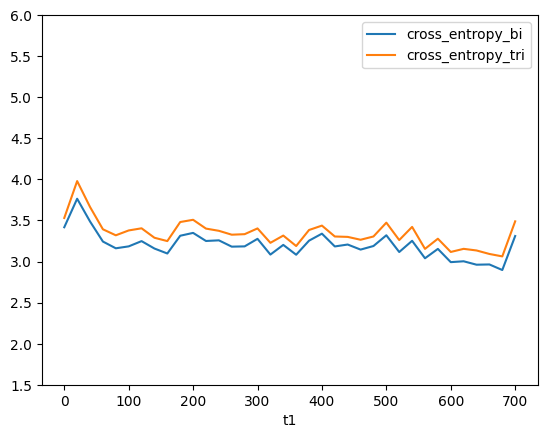

In [27]:
df_trigrama_evento_dev\
.pipe(func = get_match_splits, num_secs = 200)\
.assign(cross_entropy_bi = lambda df: -np.log(df["prop_bigram"]))\
.assign(cross_entropy_tri = lambda df: -np.log(df["prop_trigram"]))\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)[["cross_entropy_bi", "cross_entropy_tri"]].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4")\
.groupby(["period", "cat_time"], as_index = False)[["cross_entropy_bi", "cross_entropy_tri"]].mean()\
.assign(t1 = lambda df: df["cat_time"] / 10)\
.query("period == 4")\
.set_index("t1")[["cross_entropy_bi", "cross_entropy_tri"]].plot(ylim = [1.5, 6])


In [28]:
df_bigrama_evento_dev\
.assign(cross_entropy = lambda df: -np.log(df["prop_bigram"]))\
.query("season <= '2022-23'")\
.groupby("season")["cross_entropy"].mean()\
.describe()

count    5.000000
mean     3.101946
std      0.021676
min      3.076360
25%      3.093269
50%      3.100767
75%      3.103540
max      3.135793
Name: cross_entropy, dtype: float64

In [29]:
sum([3.135793, 3.093269, 3.100767, 3.076360, 3.103540])/5

3.1019458

In [30]:
df_trigrama_evento_dev\
.assign(cross_entropy = lambda df: -np.log(df["prop_trigram"]))\
.query("season <= '2022-23'")\
.groupby("season")["cross_entropy"].mean()\
.describe()

count    5.000000
mean     3.229164
std      0.026243
min      3.192643
25%      3.223321
50%      3.231104
75%      3.232550
max      3.266201
Name: cross_entropy, dtype: float64

In [31]:
sum([3.266201, 3.223321, 3.231104, 3.192643, 3.232550])/5

3.2291638

In [32]:
df_trigrama_evento_dev\
.assign(caso = lambda df: np.select([df["prop"].notna(), (df["prop"].isna()) & (df["total"] == 0), (df["prop"].isna()) & (df["total"] > 0),], ["tripla vista", "contexto nao visto", "contexto visto, alvo nao visto",], default="outro"))\
.assign(ce_tri = lambda df: -np.log(np.clip(df["prop_trigram"], 1e-12, 1)))\
.groupby(["season", "caso"])\
.agg(n = ("ce_tri", "size"),
     ce_media = ("ce_tri", "mean"),
     total_medio = ("total", "mean"))

n  ce_media  total_medio
season  caso                                                        
2018-19 contexto nao visto               1211  3.846000     0.000000
        contexto visto, alvo nao visto   7976  6.650024    93.200978
        tripla vista                    39185  2.559601  3290.787036
2019-20 contexto nao visto               1088  3.723600     0.000000
        contexto visto, alvo nao visto   7184  6.551331    88.378062
        tripla vista                    34534  2.515340  3107.577402
2020-21 contexto nao visto               1079  3.845919     0.000000
        contexto visto, alvo nao visto   6883  6.611943   107.334011
        tripla vista                    33246  2.511196  3189.378572
2021-22 contexto nao visto               1118  3.690081     0.000000
        contexto visto, alvo nao visto   7419  6.627049   105.177787
        tripla vista                    39112  2.527153  3594.086700
2022-23 contexto nao visto               1172  3.791973     0.000000
        contexto visto, alvo nao visto   7602  6.677423   109.208235
        tripla vista                    38538  2.536075  3356.183896
2023-24 contexto nao visto               1061  3.889610     0.000000
        contexto visto, alvo nao visto   5769  6.483531    80.878142
        tripla vista                    23328  2.500801  2147.883745

### Entropia cruzada n-gramas em validação tempo

In [24]:
df_unigrama_tempo\
.assign(cross_entropy = lambda df: -np.log(df["prop_unigram"]))\
.query("season <= '2022-23'")\
.groupby("season")["cross_entropy"].mean()

season
2018-19    8.170530
2019-20    8.132138
2020-21    8.085849
2021-22    8.222563
2022-23    8.119615
Name: cross_entropy, dtype: float64

In [33]:
df_bigrama_tempo_dev\
.assign(cross_entropy = lambda df: -np.log(df["prop_bigram"]))\
.query("season <= '2022-23'")\
.groupby("season")["cross_entropy"].mean()\
.describe()


count    5.000000
mean     3.014458
std      0.015397
min      2.998142
25%      3.004371
50%      3.008261
75%      3.028453
max      3.033061
Name: cross_entropy, dtype: float64

In [34]:
sum([3.028453, 3.004371, 3.033061, 3.008261, 2.998142])/5

3.0144575999999996

In [35]:
df_trigrama_tempo_dev\
.assign(cross_entropy = lambda df: -np.log(df["prop_trigram"]))\
.query("season <= '2022-23'")\
.groupby("season")["cross_entropy"].mean()\
.describe()


count    5.000000
mean     2.987508
std      0.019658
min      2.959506
25%      2.982269
50%      2.983819
75%      3.001573
max      3.010372
Name: cross_entropy, dtype: float64

In [36]:
sum([3.001573, 2.983819, 3.010372, 2.982269, 2.959506])/5

2.9875078000000004

In [37]:
df_trigrama_tempo_dev["prop_bigram"].isna().sum()

np.int64(0)

In [38]:
df_trigrama_tempo_dev["prop_trigram"].isna().sum()

np.int64(0)

### Brier Score e Brier Skill Score para validação nos n-gramas de evento

In [39]:
vetor_incerteza = [0.963789, 0.962171, 0.962774, 0.961949, 0.962596]

In [40]:
df_soma_prop2_unigrama_evento = df_unigrama_evento\
.assign(prop_unigram = lambda df: (df["size"] + (ALPHA / K_EVENTO)) / (df["total"] + ALPHA))\
.assign(prop2 = lambda df: df["prop_unigram"] ** 2)\
.groupby("season", as_index = False)\
.agg(soma_prop2_observados = ("prop2", "sum"),
     n_tokens_observados = ("target_tokens", "nunique"),
     total = ("total", "first"))\
.assign(prop_token_nao_observado = lambda df: ((ALPHA / K_EVENTO) / (df["total"] + ALPHA)))\
.assign(soma_prop2 = lambda df: (df["soma_prop2_observados"] + (K_EVENTO - df["n_tokens_observados"]) * (df["prop_token_nao_observado"] ** 2)))\
[["season", "soma_prop2"]]

df_unigrama_evento_dev\
.merge(df_soma_prop2_unigrama_evento, how = "left")\
.assign(brier_score = lambda df: (df["soma_prop2"] - 2 * df["prop_unigram"]  + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"].mean()\
.describe()

count    5.000000
mean     0.962683
std      0.000709
min      0.961969
25%      0.962219
50%      0.962621
75%      0.962798
max      0.963808
Name: brier_score, dtype: float64

In [41]:
sum([0.963808, 0.962219, 0.962798, 0.961969, 0.962621]) / 5

0.9626829999999998

In [42]:
vetor_brier_score_unigrama_evento_dev = df_unigrama_evento_dev\
.merge(df_soma_prop2_unigrama_evento, how = "left")\
.assign(brier_score = lambda df: (df["soma_prop2"] - 2 * df["prop_unigram"]  + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"].mean().to_list()

In [43]:
vetor_brier_score_unigrama_evento_dev

[0.9638082698155818,
 0.9622190152091236,
 0.9627982169425804,
 0.9619692172129319,
 0.9626212595878573]

In [49]:
10 * np.mean([1 - (i/j) for i, j in zip(vetor_brier_score_unigrama_evento_dev, vetor_incerteza)])

np.float64(-0.0002846162770113736)

In [48]:
10 * np.std([1 - (i/j) for i, j in zip(vetor_brier_score_unigrama_evento_dev, vetor_incerteza)])

np.float64(0.00010979391474114859)

In [44]:
10 * (sum([1 - (i/j) for i, j in zip(vetor_brier_score_unigrama_evento_dev, vetor_incerteza)])/5)

-0.0002846162770113736

In [50]:
# Soma dos quadrados do unigrama por temporada
df_soma_prop2_unigrama_evento = df_unigrama_evento_smooth\
.assign(prop2 = lambda df: df["prop_unigram"] ** 2)\
.groupby("season", as_index = False)\
.agg(soma_prop2_observados = ("prop2", "sum"),
     n_tokens_observados = ("target_tokens", "nunique"),
     total = ("total", "first"))\
.assign(prop_token_nao_observado = lambda df: ((ALPHA / K_EVENTO) / (df["total"] + ALPHA)))\
.assign(soma_prop2_unigram = lambda df: (df["soma_prop2_observados"] + (K_EVENTO - df["n_tokens_observados"]) * (df["prop_token_nao_observado"] ** 2)))\
[["season", "soma_prop2_unigram"]]

df_soma_prop2_bigrama_evento = df_bigrama_evento\
.merge(df_unigrama_evento_smooth[["season", "target_tokens", "prop_unigram"]], on = ["season", "target_tokens"], how = "left")\
.assign(termo_size2 = lambda df: df["size"] ** 2,
        termo_size_prop_uni = lambda df: df["size"] * df["prop_unigram"])\
.groupby(["season", "last_token"], as_index=False)\
.agg(soma_size2 = ("termo_size2", "sum"),
     soma_size_prop_uni = ("termo_size_prop_uni", "sum"),
     total = ("total", "first"))\
.merge(df_soma_prop2_unigrama_evento, on = "season", how = "left")\
.assign(soma_prop2_bigram = lambda df: (df["soma_size2"] + 2 * ALPHA * df["soma_size_prop_uni"] + (ALPHA ** 2) * df["soma_prop2_unigram"]) / ((df["total"] + ALPHA) ** 2))\
[["season", "last_token", "soma_prop2_bigram"]]

df_bigrama_evento_dev\
.merge(df_soma_prop2_bigrama_evento, on = ["season", "last_token"], how = "left")\
.merge(df_soma_prop2_unigrama_evento, on = "season", how = "left")\
.assign(soma_prop2_bigram = lambda df: df["soma_prop2_bigram"].fillna(df["soma_prop2_unigram"]))\
.assign(brier_score = lambda df: (df["soma_prop2_bigram"] - 2 * df["prop_bigram"] + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"].mean()\
.describe()

count    5.000000
mean     0.812449
std      0.003044
min      0.809167
25%      0.810785
50%      0.810910
75%      0.815445
max      0.815938
Name: brier_score, dtype: float64

In [51]:
sum([0.815938, 0.809167, 0.810910, 0.810785, 0.815445]) / 5

0.8124490000000002

In [52]:
vetor_brier_score_bigrama_evento_dev = df_bigrama_evento_dev\
.merge(df_soma_prop2_bigrama_evento, on = ["season", "last_token"], how = "left")\
.merge(df_soma_prop2_unigrama_evento, on = "season", how = "left")\
.assign(soma_prop2_bigram = lambda df: df["soma_prop2_bigram"].fillna(df["soma_prop2_unigram"]))\
.assign(brier_score = lambda df: (df["soma_prop2_bigram"] - 2 * df["prop_bigram"] + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"].mean().to_list()

In [53]:
np.mean([1 - (i/j) for i, j in zip(vetor_brier_score_bigrama_evento_dev, vetor_incerteza)])

np.float64(0.1560348238456925)

In [54]:
np.std([1 - (i/j) for i, j in zip(vetor_brier_score_bigrama_evento_dev, vetor_incerteza)])

np.float64(0.002448110281124652)

In [55]:
df_soma_prop2_trigrama_evento = df_trigrama_evento\
.merge(df_bigrama_evento_dev[["season", "last_token", "target_tokens", "prop_bigram"]].drop_duplicates(), on = ["season", "last_token", "target_tokens"], how = "left")\
.assign(termo_size2 = lambda df: df["size"] ** 2, 
        termo_size_prop_bi = lambda df: df["size"] * df["prop_bigram"])\
.groupby(["season", "last2_token", "last_token"], as_index = False)\
.agg(soma_size2 = ("termo_size2", "sum"),
     soma_size_prop_bi = ("termo_size_prop_bi", "sum"),
     total = ("total", "first"))\
.merge(df_soma_prop2_bigrama_evento, on = ["season", "last_token"], how = "left")\
.assign(soma_prop2_trigram = lambda df: (df["soma_size2"] + 2 * ALPHA * df["soma_size_prop_bi"] + (ALPHA ** 2) * df["soma_prop2_bigram"]) / ((df["total"] + ALPHA) ** 2))\
[["season", "last2_token", "last_token", "soma_prop2_trigram"]]

df_soma_prop2_trigrama_evento = df_trigrama_evento\
.merge(df_bigrama_evento_smooth, on = ["season", "last_token", "target_tokens"], how = "left")\
.assign(termo_size2 = lambda df: df["size"] ** 2, 
        termo_size_prop_bi = lambda df: df["size"] * df["prop_bigram"])\
.groupby(["season", "last2_token", "last_token"], as_index = False)\
.agg(soma_size2 = ("termo_size2", "sum"),
     soma_size_prop_bi = ("termo_size_prop_bi", "sum"),
     total = ("total", "first"))\
.merge(df_soma_prop2_bigrama_evento, on = ["season", "last_token"], how = "left")\
.assign(soma_prop2_trigram = lambda df: (df["soma_size2"] + 2 * ALPHA * df["soma_size_prop_bi"] + (ALPHA ** 2) * df["soma_prop2_bigram"]) / ((df["total"] + ALPHA) ** 2))\
[["season", "last2_token", "last_token", "soma_prop2_trigram"]]

df_trigrama_evento_dev\
.merge(df_soma_prop2_trigrama_evento, on = ["season", "last2_token", "last_token"], how = "left")\
.merge(df_soma_prop2_bigrama_evento, on = ["season", "last_token"], how = "left")\
.assign(soma_prop2_trigram = lambda df: df["soma_prop2_trigram"].fillna(df["soma_prop2_bigram"]))\
.assign(brier_score = lambda df: (df["soma_prop2_trigram"] - 2 * df["prop_trigram"] + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"].mean()\
.describe()

count    5.000000
mean     0.813614
std      0.003132
min      0.810394
25%      0.811525
50%      0.812227
75%      0.816668
max      0.817256
Name: brier_score, dtype: float64

In [56]:
sum([0.817256, 0.810394, 0.812227, 0.811525, 0.816668])/ 5

0.8136140000000001

In [57]:
vetor_brier_score_trigrama_evento_dev = df_trigrama_evento_dev\
.merge(df_soma_prop2_trigrama_evento, on = ["season", "last2_token", "last_token"], how = "left")\
.merge(df_soma_prop2_bigrama_evento, on = ["season", "last_token"], how = "left")\
.assign(soma_prop2_trigram = lambda df: df["soma_prop2_trigram"].fillna(df["soma_prop2_bigram"]))\
.assign(brier_score = lambda df: (df["soma_prop2_trigram"] - 2 * df["prop_trigram"] + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"].mean().to_list()

In [58]:
np.mean([1 - (i/j) for i, j in zip(vetor_brier_score_trigrama_evento_dev, vetor_incerteza)])

np.float64(0.1548245502912339)

In [59]:
np.std([1 - (i/j) for i, j in zip(vetor_brier_score_trigrama_evento_dev, vetor_incerteza)])

np.float64(0.0025091067101492724)

### Brier Score e Brier Skill Score para validação nos n-gramas de tempo

In [60]:
vetor_incerteza_tempo = [0.951498, 0.950880, 0.952028, 0.950739, 0.950974]

In [61]:
# 1. Unigrama suavizado do tempo: P(Delta = delta)
df_unigrama_tempo_smooth = df_unigrama_tempo\
.assign(prop_unigram_smooth = lambda df: (df["size"] + (ALPHA / K_TEMPO)) / (df["total"] + ALPHA))

# Soma dos quadrados do unigrama por temporada
df_soma_prop2_unigrama_tempo = df_unigrama_tempo_smooth\
.assign(prop2 = lambda df: df["prop_unigram_smooth"] ** 2)\
.groupby("season", as_index = False)\
.agg(soma_prop2_observados = ("prop2", "sum"),
     n_tempos_observados = ("target_time", "nunique"),
     total = ("total", "first"))\
.assign(prop_tempo_nao_observado = lambda df: ((ALPHA / K_TEMPO) / (df["total"] + ALPHA)))\
.assign(soma_prop2_unigram = lambda df: (df["soma_prop2_observados"] + (K_TEMPO - df["n_tempos_observados"]) * (df["prop_tempo_nao_observado"] ** 2)))\
[["season", "soma_prop2_unigram"]]

df_bigrama_tempo_smooth = df_bigrama_tempo\
.merge(df_unigrama_tempo_smooth[["season", "target_time", "prop_unigram_smooth"]], on = ["season", "target_time"], how = "left")\
.assign(prop_bigram_smooth = lambda df: (df["size"] + ALPHA * df["prop_unigram_smooth"]) / (df["total"] + ALPHA))

# Soma dos quadrados do bigrama por contexto (season, token)
df_soma_prop2_bigrama_tempo = df_bigrama_tempo_smooth\
.assign(termo_size2 = lambda df: df["size"] ** 2, termo_size_prop_uni = lambda df: df["size"] * df["prop_unigram_smooth"])\
.groupby(["season", "token"], as_index=False)\
.agg(soma_size2 = ("termo_size2", "sum"), 
     soma_size_prop_uni = ("termo_size_prop_uni", "sum"),
     total = ("total", "first"))\
.merge(df_soma_prop2_unigrama_tempo, on = "season", how = "left")\
.assign(soma_prop2_bigram = lambda df: (df["soma_size2"] + 2 * ALPHA * df["soma_size_prop_uni"] + (ALPHA ** 2) * df["soma_prop2_unigram"]) / ((df["total"] + ALPHA) ** 2))\
[["season", "token", "soma_prop2_bigram"]]

df_soma_prop2_trigrama_tempo = df_trigrama_tempo\
.merge(df_bigrama_tempo_smooth[["season", "token", "target_time", "prop_bigram_smooth"]], on = ["season", "token", "target_time"], how = "left")\
.assign(termo_size2 = lambda df: df["size"] ** 2,
        termo_size_prop_bi = lambda df: df["size"] * df["prop_bigram_smooth"])\
.groupby(["season", "last_token", "token"], as_index = False)\
.agg(soma_size2 = ("termo_size2", "sum"),
     soma_size_prop_bi = ("termo_size_prop_bi", "sum"),
     total = ("total", "first"))\
.merge(df_soma_prop2_bigrama_tempo, on = ["season", "token"], how = "left")\
.assign(soma_prop2_trigram = lambda df: (df["soma_size2"] + 2 * ALPHA * df["soma_size_prop_bi"] + (ALPHA ** 2) * df["soma_prop2_bigram"]) / ((df["total"] + ALPHA) ** 2))\
[["season", "last_token", "token", "soma_prop2_trigram"]]

df_trigrama_tempo_dev\
.merge(df_soma_prop2_trigrama_tempo, on = ["season", "last_token", "token"], how = "left")\
.merge(df_soma_prop2_bigrama_tempo, on = ["season", "token"], how = "left")\
.merge(df_soma_prop2_unigrama_tempo, on = "season", how = "left")\
.assign(soma_prop2_trigram = lambda df: (df["soma_prop2_trigram"].fillna(df["soma_prop2_bigram"]).fillna(df["soma_prop2_unigram"])))\
.assign(brier_score = lambda df: (df["soma_prop2_trigram"]- 2 * df["prop_trigram"] + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"]\
.mean()\
.describe()

count    5.000000
mean     0.829099
std      0.003712
min      0.823586
25%      0.827313
50%      0.829949
75%      0.832203
max      0.832443
Name: brier_score, dtype: float64

In [62]:
vetor_brier_score_bigrama_tempo_dev = df_bigrama_tempo_dev\
.merge(df_soma_prop2_bigrama_tempo, on = ["season", "token"], how = "left")\
.merge(df_soma_prop2_unigrama_tempo, on = "season", how = "left")\
.assign(soma_prop2_trigram = lambda df: (df["soma_prop2_bigram"].fillna(df["soma_prop2_unigram"])))\
.assign(brier_score = lambda df: (df["soma_prop2_bigram"]- 2 * df["prop_bigram"] + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"]\
.mean().to_list()


In [63]:
sum(vetor_brier_score_bigrama_tempo_dev)/5

0.847334327715658

In [64]:
vetor_brier_score_trigrama_tempo_dev = df_trigrama_tempo_dev\
.merge(df_soma_prop2_trigrama_tempo, on = ["season", "last_token", "token"], how = "left")\
.merge(df_soma_prop2_bigrama_tempo, on = ["season", "token"], how = "left")\
.merge(df_soma_prop2_unigrama_tempo, on = "season", how = "left")\
.assign(soma_prop2_trigram = lambda df: (df["soma_prop2_trigram"].fillna(df["soma_prop2_bigram"]).fillna(df["soma_prop2_unigram"])))\
.assign(brier_score = lambda df: (df["soma_prop2_trigram"]- 2 * df["prop_trigram"] + 1))\
.query("season <= '2022-23'")\
.groupby("season")["brier_score"]\
.mean().to_list()


In [73]:
sum(vetor_brier_score_bigrama_tempo_dev) / 5

0.847334327715658

In [69]:
np.mean([1 - (i/j) for i, j in zip(vetor_brier_score_bigrama_tempo_dev, vetor_incerteza_tempo)])

np.float64(0.1092173426770803)

In [70]:
np.std([1 - (i/j) for i, j in zip(vetor_brier_score_bigrama_tempo_dev, vetor_incerteza_tempo)])

np.float64(0.002447513714442139)

In [74]:
sum(vetor_brier_score_trigrama_tempo_dev) / 5

0.8290987846799966

In [75]:
np.mean([1 - (i/j) for i, j in zip(vetor_brier_score_trigrama_tempo_dev, vetor_incerteza_tempo)])

np.float64(0.1283882521785287)

In [76]:
np.std([1 - (i/j) for i, j in zip(vetor_brier_score_trigrama_tempo_dev, vetor_incerteza_tempo)])

np.float64(0.0032029292651654952)

### MAE n-gramas em validação tempo

In [52]:
media_uniforme_tempo = np.arange(K_TEMPO).mean()

In [53]:
df_esperado_unigrama_tempo = df_unigrama_tempo\
.assign(termo_time = lambda df: df["size"] * df["target_time"])\
.groupby("season", as_index = False)\
.agg(soma_time = ("termo_time", "sum"),
        total = ("total", "first"))\
.assign(esperado_unigram = lambda df: (df["soma_time"] + ALPHA * media_uniforme_tempo) / (df["total"] + ALPHA))\
.query("season <= '2022-23'")\
[["season", "esperado_unigram"]]

df_esperado_unigrama_tempo

,season,esperado_unigram
0,2018-19,79.242382
1,2019-20,79.173730
2,2020-21,80.629058
3,2021-22,80.586491
4,2022-23,81.000303


In [54]:
df_esperado_unigrama_tempo["esperado_unigram"].describe()

count     5.000000
mean     80.126393
std       0.853979
min      79.173730
25%      79.242382
50%      80.586491
75%      80.629058
max      81.000303
Name: esperado_unigram, dtype: float64

In [57]:
df_esperado_bigrama_tempo = df_bigrama_tempo\
.assign(termo_time = lambda df: df["size"] * df["target_time"])\
.groupby(["season", "token"], as_index = False)\
.agg(soma_time = ("termo_time", "sum"),
     total = ("total", "first"))\
.merge(df_esperado_unigrama_tempo, on = "season", how = "left")\
.assign(esperado_bigram = lambda df: (df["soma_time"] + ALPHA * df["esperado_unigram"]) / (df["total"] + ALPHA))\
.query("season <= '2022-23'")\
[["season", "token", "esperado_bigram"]]

In [61]:
df_esperado_bigrama_tempo

,season,token,esperado_bigram
0,2018-19,1,65.482138
1,2018-19,2,70.255466
2,2018-19,3,102.002463
3,2018-19,4,102.261061
4,2018-19,5,64.458387
...,...,...,...
2882,2022-23,596,27.702744
2883,2022-23,597,44.105423
2884,2022-23,598,62.631738
2885,2022-23,599,26.934608


In [62]:
df_esperado_trigrama_tempo = df_trigrama_tempo\
.assign(termo_time = lambda df: df["size"] * df["target_time"])\
.groupby(["season", "last_token", "token"], as_index = False)\
.agg(soma_time = ("termo_time", "sum"),
     total = ("total", "first"))\
.merge(df_esperado_bigrama_tempo, on = ["season", "token"], how = "left")\
.merge(df_esperado_unigrama_tempo, on = "season", how = "left")\
.assign(esperado_bigram = lambda df: df["esperado_bigram"].fillna(df["esperado_unigram"]))\
.assign(esperado_trigram = lambda df: (df["soma_time"] + ALPHA * df["esperado_bigram"]) / (df["total"] + ALPHA))\
[["season", "last_token", "token", "esperado_trigram"]]

In [63]:
df_mae_bigrama_tempo_dev = df_trigrama_tempo_dev\
.merge(df_esperado_bigrama_tempo, on = ["season", "token"], how = "left")\
.merge(df_esperado_unigrama_tempo, on = "season", how = "left")\
.assign(esperado_bigram = lambda df: df["esperado_bigram"].fillna(df["esperado_unigram"]))\
.assign(mae = lambda df: np.abs(df["target_time"] - df["esperado_bigram"]))

In [66]:
df_mae_bigrama_tempo_dev.query("season <= '2022-23'").groupby("season")["mae"].mean().describe()

count     5.000000
mean     36.198172
std       0.207950
min      35.837876
25%      36.241782
50%      36.243201
75%      36.299850
max      36.368148
Name: mae, dtype: float64

In [75]:
sum([36.368148, 35.837876, 36.299850, 36.243201, 36.241782]) / 5

36.1981714

In [67]:
df_mae_trigrama_tempo_dev = df_trigrama_tempo_dev\
.merge(df_esperado_trigrama_tempo, on = ["season", "last_token", "token"], how = "left")\
.merge(df_esperado_bigrama_tempo, on = ["season", "token"], how = "left")\
.merge(df_esperado_unigrama_tempo, on = "season", how = "left")\
.assign(esperado_bigram = lambda df: df["esperado_bigram"].fillna(df["esperado_unigram"]))\
.assign(esperado_trigram = lambda df: df["esperado_trigram"].fillna(df["esperado_bigram"]))\
.assign(mae = lambda df: np.abs(df["target_time"] - df["esperado_trigram"]))

In [69]:
df_mae_trigrama_tempo_dev.query("season <= '2022-23'").groupby("season")["mae"].mean().describe()

count     5.000000
mean     29.018595
std       0.281486
min      28.731216
25%      28.830603
50%      28.912452
75%      29.212750
max      29.405954
Name: mae, dtype: float64

In [70]:
sum([29.212750, 28.830603, 29.405954, 28.912452, 28.731216]) / 5

29.018594999999998

### Entropia cruzada n-gramas em validação evento ao longo da partida

In [315]:
df_entropia_cruzada_ngrama_eventos_dev = pd.concat(objs = [
    df_trigrama_evento_dev\
    .query("period <= 4 & season <= '2022-23'")\
    .assign(cross_entropy = lambda df: -np.log(df["prop_unigram"]))\
    .pipe(func = get_match_splits, num_secs = 200)\
    .astype({"cat_time": "str"})\
    .groupby(["season", "period", "cat_time"], as_index = False)["cross_entropy"].mean()\
    .assign(modelo = 'unigrama'),

    df_trigrama_evento_dev\
    .query("period <= 4 & season <= '2022-23'")\
    .assign(cross_entropy = lambda df: -np.log(df["prop_bigram"]))\
    .pipe(func = get_match_splits, num_secs = 200)\
    .astype({"cat_time": "str"})\
    .groupby(["season", "period", "cat_time"], as_index = False)["cross_entropy"].mean()\
    .assign(modelo = 'bigrama'),

    df_trigrama_evento_dev\
    .query("period <= 4 & season <= '2022-23'")\
    .assign(cross_entropy = lambda df: -np.log(df["prop_trigram"]))\
    .pipe(func = get_match_splits, num_secs = 200)\
    .astype({"cat_time": "str"})\
    .groupby(["season", "period", "cat_time"], as_index = False)["cross_entropy"].mean()\
    .assign(modelo = 'trigrama'),

], axis = 0)\
.groupby(["period", "cat_time", "modelo"], as_index = False, dropna = False)["cross_entropy"].mean()


In [316]:
df_entropia_cruzada_ngrama_eventos_dev

,period,cat_time,modelo,cross_entropy
0,1,0-200,bigrama,4.148574
1,1,0-200,trigrama,4.408270
2,1,0-200,unigrama,5.515155
3,1,1000-1200,bigrama,3.149354
4,1,1000-1200,trigrama,3.289852
...,...,...,...,...
427,4,7000-7200,trigrama,3.462076
428,4,7000-7200,unigrama,4.153465
429,4,800-1000,bigrama,3.169004
430,4,800-1000,trigrama,3.323652


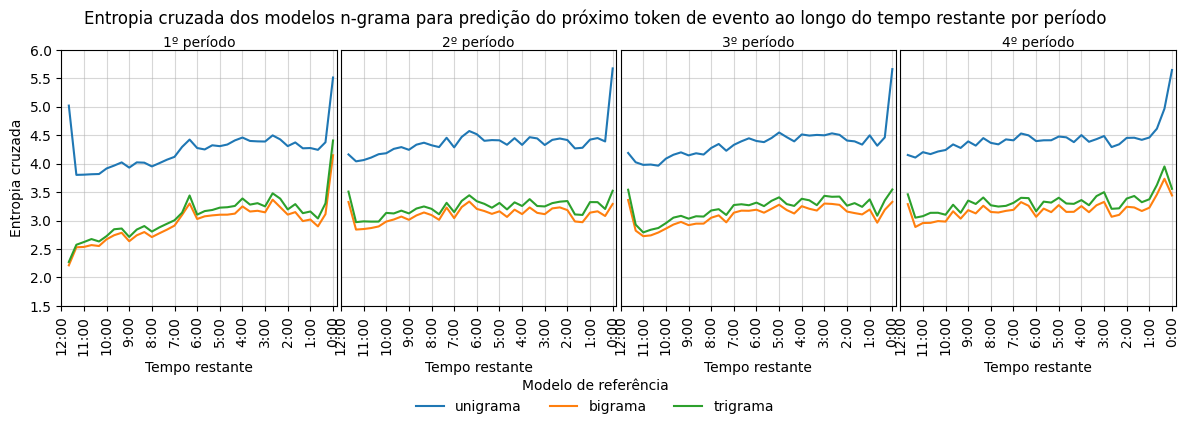

In [317]:
fig, ax = plt.subplots(1, 4, figsize = (12, 4))
ordem_modelos = ["unigrama", "bigrama", "trigrama"]
for i in range(4):

    df_entropia_cruzada_ngrama_eventos_dev\
    .assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"] / 10)\
    .pivot_table(index = "t1", columns = "modelo", values = "cross_entropy")\
    .reindex(columns = ordem_modelos)\
    .plot(ax = ax[i], legend = False)

    bounds_y = [1.5, 6]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
#fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize = 15, y = 0.98)
fig.suptitle("Entropia cruzada dos modelos n-grama para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.12))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

### Entropia cruzada n-gramas em validação tempo ao longo da partida


In [328]:
df_entropia_cruzada_ngrama_tempo_dev = pd.concat(objs = [
    df_trigrama_tempo_dev\
    .query("period <= 4 & season <= '2022-23'")\
    .assign(cross_entropy = lambda df: -np.log(df["prop_unigram"]))\
    .pipe(func = get_match_splits, num_secs = 200)\
    .astype({"cat_time": "str"})\
    .groupby(["season", "period", "cat_time"], as_index = False)["cross_entropy"].mean()\
    .assign(modelo = 'unigrama'),

    df_trigrama_tempo_dev\
    .query("period <= 4 & season <= '2022-23'")\
    .assign(cross_entropy = lambda df: -np.log(df["prop_bigram"]))\
    .pipe(func = get_match_splits, num_secs = 200)\
    .astype({"cat_time": "str"})\
    .groupby(["season", "period", "cat_time"], as_index = False)["cross_entropy"].mean()\
    .assign(modelo = 'bigrama'),

    df_trigrama_tempo_dev\
    .query("period <= 4 & season <= '2022-23'")\
    .assign(cross_entropy = lambda df: -np.log(df["prop_trigram"]))\
    .pipe(func = get_match_splits, num_secs = 200)\
    .astype({"cat_time": "str"})\
    .groupby(["season", "period", "cat_time"], as_index = False)["cross_entropy"].mean()\
    .assign(modelo = 'trigrama'),

], axis = 0)\
.groupby(["period", "cat_time", "modelo"], as_index = False, dropna = False)["cross_entropy"].mean()


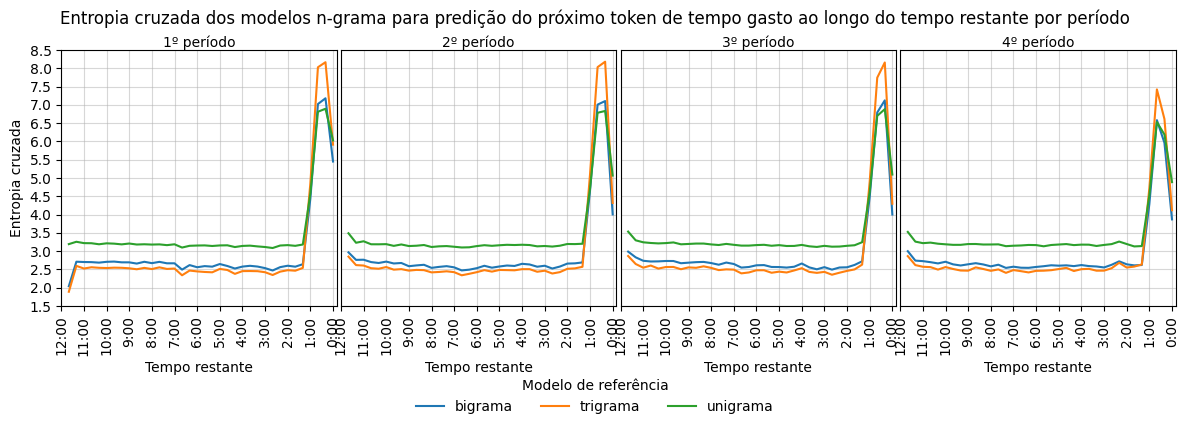

In [329]:
fig, ax = plt.subplots(1, 4, figsize = (12, 4))
ordem_modelos = ["unigrama", "bigrama", "trigrama"]
for i in range(4):

    df_entropia_cruzada_ngrama_tempo_dev\
    .query("period == (@i + 1)")\
    .assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
    .assign(t1 = lambda df: df["cat_time"]/10)\
    .pivot_table(index = "t1", columns = "modelo", values = "cross_entropy")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [1.5, 8.5]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Entropia cruzada dos modelos n-grama para predição do próximo token de tempo gasto ao longo do tempo restante por período", fontsize = 12, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.12))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

### Brier Score e Brier Skill Score em validaçao evento ao longo da partida

,period,cat_time,brier_score
35,1,7000,0.992466
34,1,6800,0.945552
33,1,6600,0.947975
32,1,6400,0.946591
31,1,6200,0.945793
...,...,...,...
112,4,800,0.961802
111,4,600,0.961099
110,4,400,0.966635
109,4,200,0.973332


In [262]:
df_brier_score_unigrama_evento_dev_20secs = df_unigrama_evento_dev\
.merge(df_soma_prop2_unigrama_evento, how = "left")\
.assign(brier_score = lambda df: (df["soma_prop2_unigram"] - 2 * df["prop_unigram"]  + 1))\
.pipe(func = get_match_splits, num_secs = 200)\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)["brier_score"].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4 & season <= '2022-23'")\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["brier_score"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])


In [266]:
df_bss_unigrama_evento_dev_20secs = df_unigrama_evento_dev\
.merge(df_soma_prop2_unigrama_evento, how = "left")\
.assign(brier_score = lambda df: (df["soma_prop2_unigram"] - 2 * df["prop_unigram"]  + 1))\
.pipe(func = get_match_splits, num_secs = 200)\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)["brier_score"].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4 & season <= '2022-23'")\
.assign(seasondata = lambda df: df["season"].str.replace("-", ""))\
.merge(df_incerteza_evento, how = 'left')\
.assign(bss = lambda df: 1 - (df["brier_score"] / df["incerteza"]))\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["bss"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])

In [268]:
df_brier_score_bigrama_evento_dev_20secs = df_token_features\
.query("season_split == 'dev'")\
.assign(last_token = lambda df: df.groupby(["game_id"])["target_tokens"].shift(1))\
.assign(last_token = lambda df: df["last_token"].fillna(0))\
[["season", "period", "remaining_time", "last_token", "target_tokens"]]\
.astype({"last_token": "int"})\
.merge(df_bigrama_evento[["season", "last_token", "target_tokens", "size", "prop"]], on = ["season", "last_token", "target_tokens"], how = "left")\
.merge(df_bigrama_evento[["season", "last_token", "total"]].drop_duplicates(), on = ["season", "last_token"], how = "left")\
.merge(df_unigrama_evento_smooth[["season", "target_tokens", "prop_unigram"]].drop_duplicates(), on = ["season", "target_tokens"], how = "left")\
.assign(size = lambda df: df["size"].fillna(0))\
.assign(total = lambda df: df["total"].fillna(0))\
.assign(prop_bigram = lambda df: (df["size"] + (ALPHA * df["prop_unigram"])) / (df["total"] + ALPHA))\
.merge(df_soma_prop2_bigrama_evento, on = ["season", "last_token"], how = "left")\
.merge(df_soma_prop2_unigrama_evento, on = "season", how = "left")\
.assign(soma_prop2_bigram = lambda df: df["soma_prop2_bigram"].fillna(df["soma_prop2_unigram"]))\
.assign(brier_score = lambda df: df["soma_prop2_bigram"] - 2 * df["prop_bigram"] + 1)\
.pipe(func = get_match_splits, num_secs = 200)\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)["brier_score"].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4 & season <= '2022-23'")


In [269]:
df_brier_score_bigrama_evento_dev_20secs\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["brier_score"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])


,period,cat_time,brier_score
35,1,7000,0.732847
34,1,6800,0.754531
33,1,6600,0.770816
32,1,6400,0.752732
31,1,6200,0.758068
...,...,...,...
112,4,800,0.828585
111,4,600,0.820962
110,4,400,0.850433
109,4,200,0.859665


In [272]:
df_bss_bigrama_evento_dev_20secs = df_brier_score_bigrama_evento_dev_20secs\
.assign(seasondata = lambda df: df["season"].str.replace("-", ""))\
.merge(df_incerteza_evento, how = 'left')\
.assign(bss = lambda df: 1 - (df["brier_score"] / df["incerteza"]))\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["bss"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])

In [275]:
df_brier_score_trigrama_evento_dev_20secs = df_trigrama_evento_dev\
.merge(df_soma_prop2_trigrama_evento, on = ["season", "last2_token", "last_token"], how = "left")\
.merge(df_soma_prop2_bigrama_evento, on = ["season", "last_token"], how = "left")\
.assign(soma_prop2_trigram = lambda df: df["soma_prop2_trigram"].fillna(df["soma_prop2_bigram"]))\
.assign(brier_score = lambda df: df["soma_prop2_trigram"] - 2 * df["prop_trigram"] + 1)\
.pipe(func = get_match_splits, num_secs = 200)\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)["brier_score"].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4 & season <= '2022-23'")

In [276]:
df_brier_score_trigrama_evento_dev_20secs\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["brier_score"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])


,period,cat_time,brier_score
35,1,7000,0.733424
34,1,6800,0.755827
33,1,6600,0.773830
32,1,6400,0.755379
31,1,6200,0.759817
...,...,...,...
112,4,800,0.832325
111,4,600,0.824760
110,4,400,0.851263
109,4,200,0.862430


In [277]:
df_bss_trigrama_evento_dev_20secs = df_brier_score_trigrama_evento_dev_20secs\
.assign(seasondata = lambda df: df["season"].str.replace("-", ""))\
.merge(df_incerteza_evento, how = 'left')\
.assign(bss = lambda df: 1 - (df["brier_score"] / df["incerteza"]))\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["bss"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])

In [278]:
df_bss_evento_dev_20secs = pd.concat(objs = [
    df_bss_unigrama_evento_dev_20secs.assign(modelo = "unigrama"),
    df_bss_bigrama_evento_dev_20secs.assign(modelo = "bigrama"),
    df_bss_trigrama_evento_dev_20secs.assign(modelo = "trigrama")
    ], axis = 0)



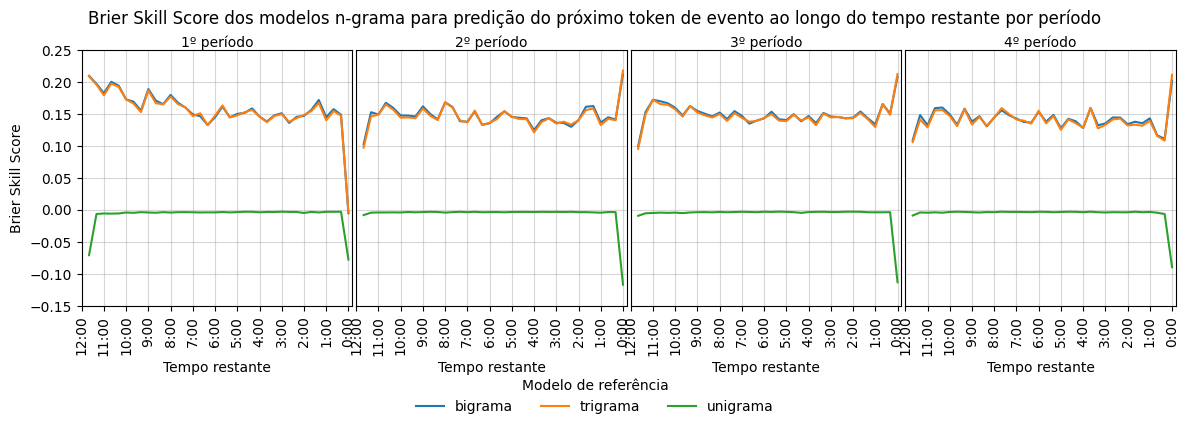

In [284]:
fig, ax = plt.subplots(1, 4, figsize = (12, 4))

for i in range(4):
    df_bss_evento_dev_20secs\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"] / 10)\
    .pivot_table(index = "t1", columns = "modelo", values = "bss")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [-0.15, 0.25]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score dos modelos n-grama para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.12))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

### Brier Score e Brier Skill Score em validaçao tempo ao longo da partida

In [285]:
df_brier_score_bigrama_tempo_dev_20secs = df_bigrama_tempo_dev\
.merge(df_soma_prop2_bigrama_tempo, on = ["season", "token"], how = "left")\
.merge(df_soma_prop2_unigrama_tempo, on = ["season"], how = "left")\
.assign(soma_prop2_bigram = lambda df: df["soma_prop2_bigram"].fillna(df["soma_prop2_unigram"]))\
.assign(brier_score = lambda df: df["soma_prop2_bigram"] - 2 * df["prop_bigram"] + 1)\
.pipe(func = get_match_splits, num_secs = 200)\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)["brier_score"].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4 & season <= '2022-23'")

In [286]:
df_brier_score_trigrama_tempo_dev_20secs = df_trigrama_tempo_dev\
.merge(df_soma_prop2_trigrama_tempo, on = ["season", "last_token", "token"], how = "left")\
.merge(df_soma_prop2_bigrama_tempo, on = ["season", "token"], how = "left")\
.assign(soma_prop2_trigram = lambda df: df["soma_prop2_trigram"].fillna(df["soma_prop2_bigram"]))\
.assign(brier_score = lambda df: df["soma_prop2_trigram"] - 2 * df["prop_trigram"] + 1)\
.pipe(func = get_match_splits, num_secs = 200)\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)["brier_score"].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4 & season <= '2022-23'")

In [287]:
df_brier_score_trigrama_tempo_dev_20secs\
.pivot_table(index = ["period", "cat_time"], columns = "season", values = "brier_score")


season            2018-19   2019-20   2020-21   2021-22   2022-23
period cat_time                                                  
1      0         0.897063  0.901903  0.907452  0.927658  0.901755
       200       1.030619  1.005102  1.026120  0.970905  1.029056
       400       0.989966  1.000498  1.018713  1.031458  1.011598
       600       0.851436  0.852016  0.870836  0.872942  0.883916
       800       0.841173  0.819907  0.807210  0.820982  0.835333
...                   ...       ...       ...       ...       ...
4      6200      0.822545  0.843051  0.834006  0.834890  0.841429
       6400      0.844228  0.824175  0.864846  0.848893  0.848791
       6600      0.850559  0.850016  0.851004  0.850245  0.842159
       6800      0.859591  0.849392  0.878540  0.876718  0.847770
       7000      0.907725  0.902734  0.881489  0.917424  0.898863

[144 rows x 5 columns]

In [288]:
df_brier_score_trigrama_tempo_dev_20secs\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["brier_score"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])

,period,cat_time,brier_score
35,1,7000,0.595093
34,1,6800,0.868578
33,1,6600,0.861373
32,1,6400,0.865853
31,1,6200,0.861067
...,...,...,...
112,4,800,0.820260
111,4,600,0.851256
110,4,400,0.970526
109,4,200,0.914421


In [289]:
df_brier_score_trigrama_tempo_dev_20secs\
.assign(seasondata = lambda df: df["season"].str.replace("-", ""))\
.merge(df_incerteza_tempo, how = 'left')\
.assign(bss = lambda df: 1 - (df["brier_score"] / df["incerteza"]))\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["bss"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])

,period,cat_time,bss
35,1,7000,0.304019
34,1,6800,0.075139
33,1,6600,0.082208
32,1,6400,0.075854
31,1,6200,0.078264
...,...,...,...
112,4,800,0.125470
111,4,600,0.104464
110,4,400,0.005224
109,4,200,0.045259


In [290]:
df_bss_bigrama_tempo_dev_20secs = df_brier_score_bigrama_tempo_dev_20secs\
.assign(seasondata = lambda df: df["season"].str.replace("-", ""))\
.merge(df_incerteza_tempo, how = 'left')\
.assign(bss = lambda df: 1 - (df["brier_score"] / df["incerteza"]))\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["bss"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])

In [291]:
df_bss_trigrama_tempo_dev_20secs = df_brier_score_trigrama_tempo_dev_20secs\
.assign(seasondata = lambda df: df["season"].str.replace("-", ""))\
.merge(df_incerteza_tempo, how = 'left')\
.assign(bss = lambda df: 1 - (df["brier_score"] / df["incerteza"]))\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["bss"].mean()\
.sort_values(["period", "cat_time"], ascending = [True, False])

In [292]:
df_bss_tempo_dev_20secs = pd.concat(objs = [
    df_bss_bigrama_tempo_dev_20secs.assign(modelo = "bigrama"),
    df_bss_trigrama_tempo_dev_20secs.assign(modelo = "trigrama")
    ], axis = 0)



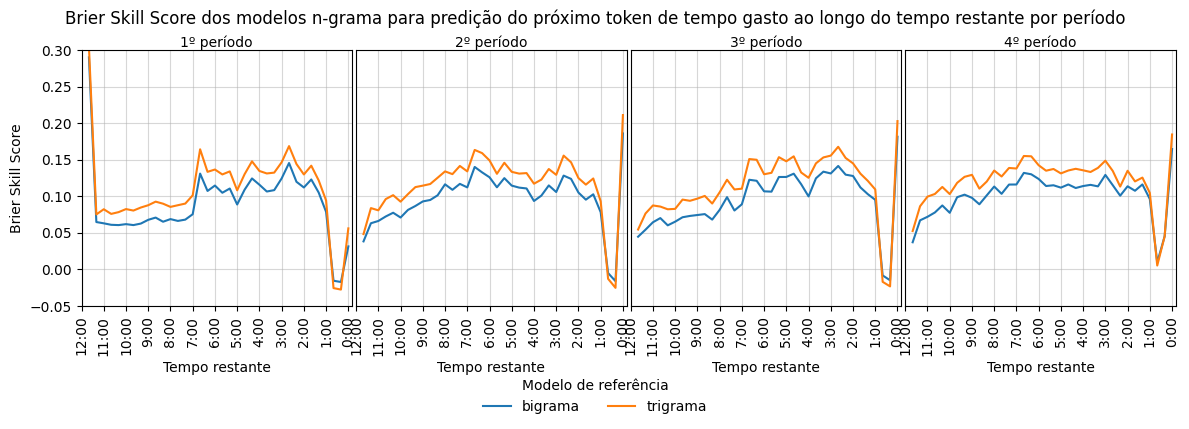

In [293]:
fig, ax = plt.subplots(1, 4, figsize = (12, 4))

for i in range(4):
    df_bss_tempo_dev_20secs\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"]/10)\
    .pivot_table(index = "t1", columns = "modelo", values = "bss")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [-0.05, 0.3]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score dos modelos n-grama para predição do próximo token de tempo gasto ao longo do tempo restante por período", fontsize = 12, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.12))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

### MAE n-gramas em validação tempo ao longo da partida

In [296]:
df_mae_bigrama_tempo_dev_20secs = df_mae_bigrama_tempo_dev\
.pipe(func = get_match_splits, num_secs = 200)\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)["mae"].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4 & season <= '2022-23'")\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["mae"].mean()

In [297]:
df_mae_trigrama_tempo_dev_20secs = df_mae_trigrama_tempo_dev\
.pipe(func = get_match_splits, num_secs = 200)\
.groupby(["season", "period", "cat_time"], observed = True, as_index = False)["mae"].mean()\
.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.query("period <= 4 & season <= '2022-23'")\
.groupby(["period", "cat_time"], as_index = False, dropna = False)["mae"].mean()

In [298]:
df_mae_tempo_dev_20secs = pd.concat(objs = [
    df_mae_bigrama_tempo_dev_20secs.assign(modelo = "bigrama"),
    df_mae_trigrama_tempo_dev_20secs.assign(modelo = "trigrama")
    ], axis = 0)



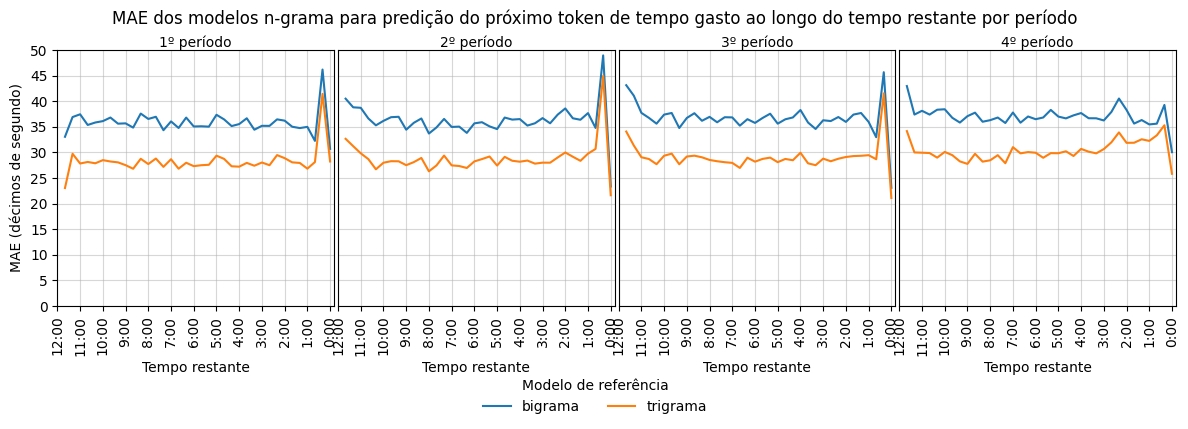

In [299]:
fig, ax = plt.subplots(1, 4, figsize = (12, 4))

for i in range(4):
    df_mae_tempo_dev_20secs\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"]/10)\
    .pivot_table(index = "t1", columns = "modelo", values = "mae")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [0, 50]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE (décimos de segundo)")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("MAE dos modelos n-grama para predição do próximo token de tempo gasto ao longo do tempo restante por período", fontsize = 12, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.12))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

### Salvando os resultados

In [300]:
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\RefModels\\"

In [322]:
df_metrics_by_time = df_bss_evento_dev_20secs\
.merge(df_entropia_cruzada_ngrama_eventos_dev.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int")), how = "left")

df_metrics_by_time.to_parquet(models_token_metrics_folder + "metrics_by_time.parquet", index = False, compression = "zstd")

In [333]:
df_metrics_by_time_TIME_SIZE = df_bss_tempo_dev_20secs\
.merge(df_entropia_cruzada_ngrama_tempo_dev.assign(cat_time = lambda df: df["cat_time"].str.split("-").str[0].astype("int")), how = "left")\
.merge(df_mae_tempo_dev_20secs, how = "left")

df_metrics_by_time_TIME_SIZE.to_parquet(models_token_metrics_folder + "metrics_by_time_TIME_SIZE.parquet", index = False, compression = "zstd")